### MODEL TRAINING NOTEBOOK FOR FORECASTING MODEL (LINE 6)

In [1]:
import pandas as pd
import numpy as np
from pathlib import Path
from scipy.optimize import curve_fit
import matplotlib.pyplot as plt


pd.set_option('display.max_columns', None)

In [2]:
path = Path('cashflows_with_sq')
projects = {}

for file in sorted(path.glob('*.csv'), key=lambda p: p.name):
    current_df = pd.read_csv(file)
    file_name = file.stem
    projects[file_name] = current_df

In [3]:
# Some formatting/ cleaning up stuff
for name, df in projects.items():
    df_cleaned = df.iloc[:, 1:].copy()

    if len(df_cleaned) > 0:
        df_cleaned.iat[-1, 0] = "Total"

        start_col_idx = 6
        if df_cleaned.shape[1] > start_col_idx:
            last_row = df_cleaned.iloc[[-1], start_col_idx:]
            cleaned_last_row = (
                last_row.astype("string")
                .apply(lambda s: s.str.split(r"\r\n|\n|\r", regex=True).str[0])
            )
            df_cleaned.iloc[-1, start_col_idx:] = cleaned_last_row.iloc[0].to_numpy()

    df_cleaned = df_cleaned.reset_index(drop=True)
    projects[name] = df_cleaned

In [4]:
timeline_dates = pd.date_range(start='2011-01-01', end='2027-06-01', freq='MS')
master_timeline = timeline_dates.strftime('%b %Y').tolist()

for name, df in projects.items():
    static_columns = list(df.columns[:7])
    all_desired_columns = static_columns + master_timeline
    df_unified = df.reindex(columns=all_desired_columns, fill_value=0)
    projects[name] = df_unified

In [5]:
# Drop all categories and leave only line 6 totals
for name, df in projects.items():
    line6_only = df[df["Line Item"].astype(str).eq("06")].copy()
    line6_only = line6_only.drop(columns=["Line Item", "Description"])
    projects[name] = line6_only.reset_index(drop=True)

In [6]:
# Add project code as first column
for name, df in projects.items():
    if df.empty:
        continue

    if "Project Code" in df.columns:
        df = df.drop(columns=["Project Code"])
    df.insert(0, "Project Code", name)

    projects[name] = df

In [7]:
# Squish all projects into a single dataframe
non_empty_projects = [df for df in projects.values() if not df.empty]
all_projects_df = pd.concat(non_empty_projects, ignore_index=True)

In [8]:
import os

# Load gross square footage and merge into all_projects_df
gross_sq_path = os.path.join(path, "gross_sq.csv") if os.path.exists(os.path.join(path, "gross_sq.csv")) else "gross_sq.csv"
gross_sq = pd.read_csv(gross_sq_path)

# Merge
all_projects_df = all_projects_df.merge(
    gross_sq[["Project Code", "Gross Sq Footage"]],
    on="Project Code",
    how="left",
)

if "Gross Sq Footage" in all_projects_df.columns:
    cols = list(all_projects_df.columns)
    cols.insert(1, cols.pop(cols.index("Gross Sq Footage")))
    all_projects_df = all_projects_df[cols]

# Remove "Actuals" columns (I don't think we need these?)
cols_to_drop = ["Actuals To Date", "Actuals + Projections"]
all_projects_df = all_projects_df.drop(columns=cols_to_drop, errors="ignore")

In [9]:
# Convert monthly spend to cumulative sum
timeline_cols = all_projects_df.columns[5:]

all_projects_df[timeline_cols] = (
    all_projects_df[timeline_cols]
    .astype(str)
    .replace({',': '', r'\(': '-', r'\)': ''}, regex=True)
    .astype(float)
)

all_projects_df[timeline_cols] = all_projects_df[timeline_cols].cumsum(axis=1)
all_projects_df.head(40)

,Project Code,Gross Sq Footage,Projected Budget,Projected Commitments,Estimate at Completion,Jan 2011,Feb 2011,Mar 2011,Apr 2011,May 2011,Jun 2011,Jul 2011,Aug 2011,Sep 2011,Oct 2011,Nov 2011,Dec 2011,Jan 2012,Feb 2012,Mar 2012,Apr 2012,May 2012,Jun 2012,Jul 2012,Aug 2012,Sep 2012,Oct 2012,Nov 2012,Dec 2012,Jan 2013,Feb 2013,Mar 2013,Apr 2013,May 2013,Jun 2013,Jul 2013,Aug 2013,Sep 2013,Oct 2013,Nov 2013,Dec 2013,Jan 2014,Feb 2014,Mar 2014,Apr 2014,May 2014,Jun 2014,Jul 2014,Aug 2014,Sep 2014,Oct 2014,Nov 2014,Dec 2014,Jan 2015,Feb 2015,Mar 2015,Apr 2015,May 2015,Jun 2015,Jul 2015,Aug 2015,Sep 2015,Oct 2015,Nov 2015,Dec 2015,Jan 2016,Feb 2016,Mar 2016,Apr 2016,May 2016,Jun 2016,Jul 2016,Aug 2016,Sep 2016,Oct 2016,Nov 2016,Dec 2016,Jan 2017,Feb 2017,Mar 2017,Apr 2017,May 2017,Jun 2017,Jul 2017,Aug 2017,Sep 2017,Oct 2017,Nov 2017,Dec 2017,Jan 2018,Feb 2018,Mar 2018,Apr 2018,May 2018,Jun 2018,Jul 2018,Aug 2018,Sep 2018,Oct 2018,Nov 2018,Dec 2018,Jan 2019,Feb 2019,Mar 2019,Apr 2019,May 2019,Jun 2019,Jul 2019,Aug 2019,Sep 2019,Oct 2019,Nov 2019,Dec 2019,Jan 2020,Feb 2020,Mar 2020,Apr 2020,May 2020,Jun 2020,Jul 2020,Aug 2020,Sep 2020,Oct 2020,Nov 2020,Dec 2020,Jan 2021,Feb 2021,Mar 2021,Apr 2021,May 2021,Jun 2021,Jul 2021,Aug 2021,Sep 2021,Oct 2021,Nov 2021,Dec 2021,Jan 2022,Feb 2022,Mar 2022,Apr 2022,May 2022,Jun 2022,Jul 2022,Aug 2022,Sep 2022,Oct 2022,Nov 2022,Dec 2022,Jan 2023,Feb 2023,Mar 2023,Apr 2023,May 2023,Jun 2023,Jul 2023,Aug 2023,Sep 2023,Oct 2023,Nov 2023,Dec 2023,Jan 2024,Feb 2024,Mar 2024,Apr 2024,May 2024,Jun 2024,Jul 2024,Aug 2024,Sep 2024,Oct 2024,Nov 2024,Dec 2024,Jan 2025,Feb 2025,Mar 2025,Apr 2025,May 2025,Jun 2025,Jul 2025,Aug 2025,Sep 2025,Oct 2025,Nov 2025,Dec 2025,Jan 2026,Feb 2026,Mar 2026,Apr 2026,May 2026,Jun 2026,Jul 2026,Aug 2026,Sep 2026,Oct 2026,Nov 2026,Dec 2026,Jan 2027,Feb 2027,Mar 2027,Apr 2027,May 2027,Jun 2027
0,5018,99812.0,"2,529.00","2,529.00","2,529.00",0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,27.5,137.5,220.0,803.5,1027.5,1222.0,1414.5,1442.0,1442.0,1442.0,1560.0,1560.0,1560.0,1560.0,1560.0,1560.0,1560.0,1734.0,1792.0,2227.0,2227.0,2374.0,2374.0,2374.0,2374.0,2374.0,2404.0,2404.0,2404.0,2404.0,2404.00,2404.00,2404.0,2404.0,2404.00,2404.00,2529.00,2529.00,2529.00,2529.00,2529.00,2529.00,2529.00,2529.00,2529.00,2529.00,2529.00,2529.00,2529.00,2529.00,2529.00,2529.00,2529.00,2529.00,2529.00,2529.00,2529.00,2529.00,2529.00,2529.00,2529.00,2529.00,2529.00,2529.00,2529.00,2529.00,2529.00,2529.00,2529.00,2529.00,2529.00,2529.00,2529.00,2529.00,2529.00,2529.00,2529.00,2529.00,2529.00,2529.00,2529.00,2529.00,2529.00,2529.00,2529.00,2529.00,2529.00,2529.00,2529.00,2529.00,2529.00,2529.00,2529.00,2529.00,2529.00,2529.00,2529.00,2529.00,2529.00,2529.00,2529.00,2529.00,2529.00,2529.00,2529.00,2529.00,2529.00,2529.00,2529.00,2529.00,2529.00,2529.00,2529.00,2529.00,2529.00,2529.00,2529.00,2529.00,2529.00,2529.00,2529.00,2529.00,2529.00,2529.00,2529.00,2529.00,2529.00,2529.00,2529.00,2529.00,2529.00,2529.00,2529.00,2529.00,2529.00,2529.00,2529.00,2529.00,2529.00,2529.00,2529.00
1,5058,1441000.0,"5,836,706.92","5,224,891.00","5,891,123.92",0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,12609.5,35572.0,54253.5,85152.5,136196.5,136196.5,173012.5,257806.5,257806.5,299599.0,351101.0,411102.5,491595.0,643037.6,643037.6,725450.5,806238.0,939025.5,1041920.5,1143465.5,1261018.0,1431773.0,1302884.0,1302884.0,1423089.00,1530321.50,1678956.5,1800194.0,1941526.75,2067236.25,2318135.50,2318135.50,2453793.25,2546746.25,2663337.50,2764077.00,2859559.50,2960909.50,3083949.75,3185654.75,3279878.25,3375637.00,3476543.25,3577757.75,3679391.

In [10]:
# Remove project 5149 (no spending?)
all_projects_df = all_projects_df[all_projects_df["Project Code"].astype(str) != "5149"].reset_index(drop=True)

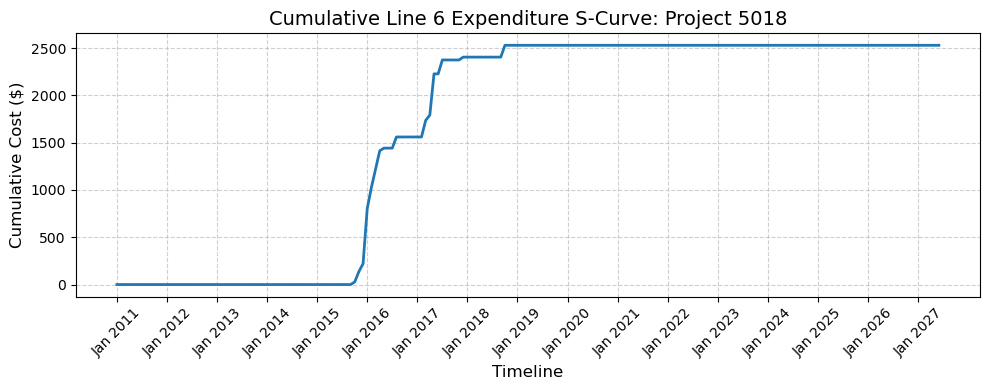

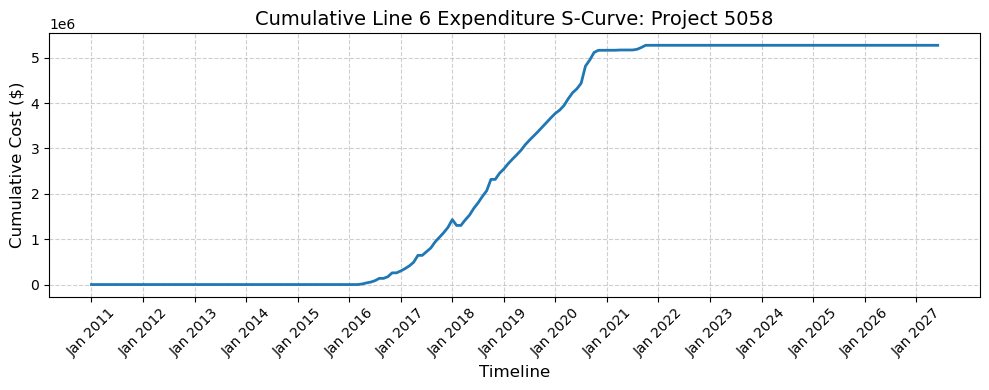

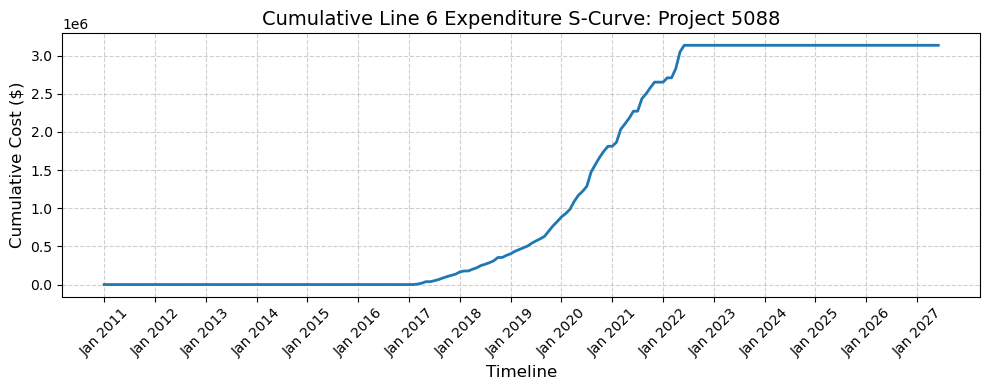

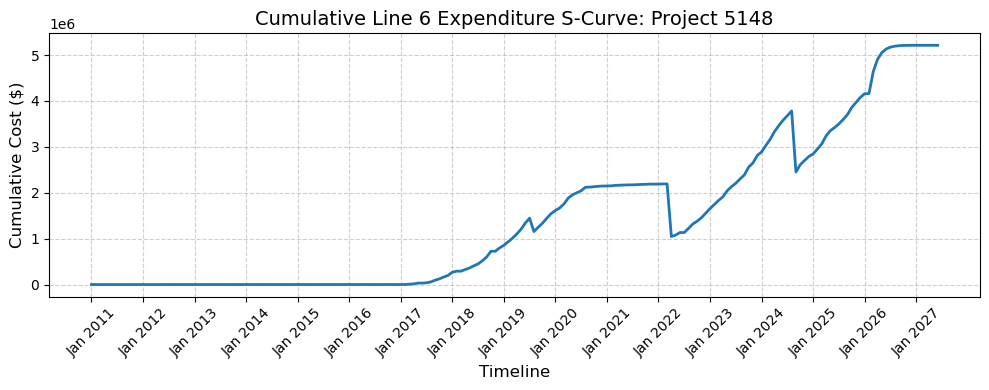

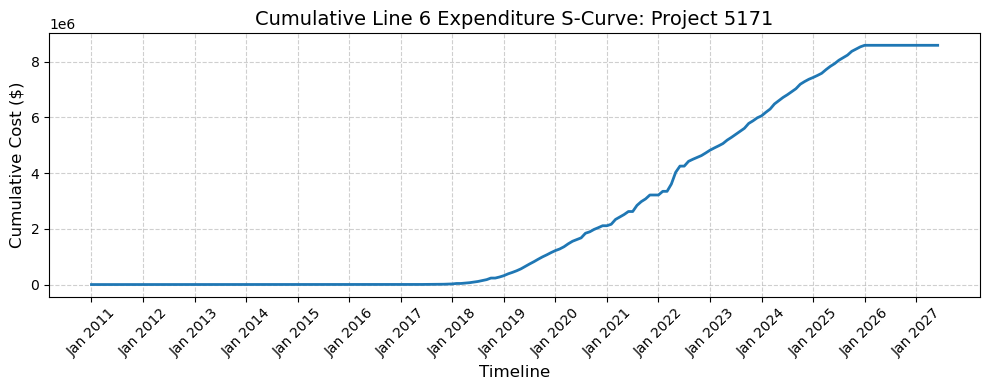

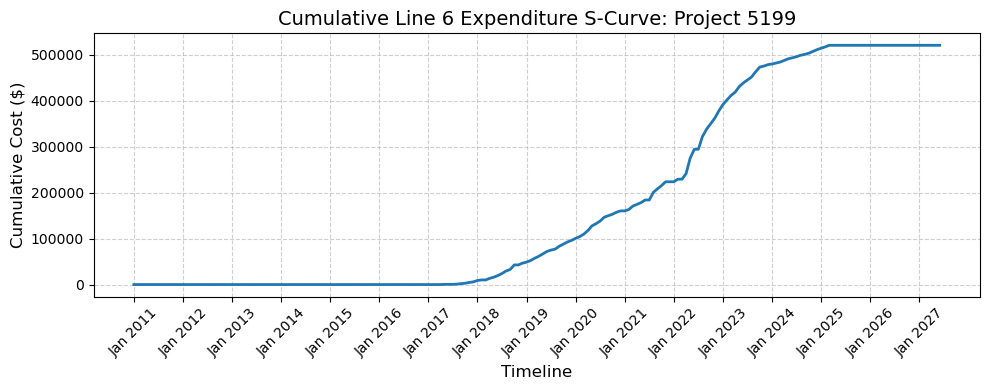

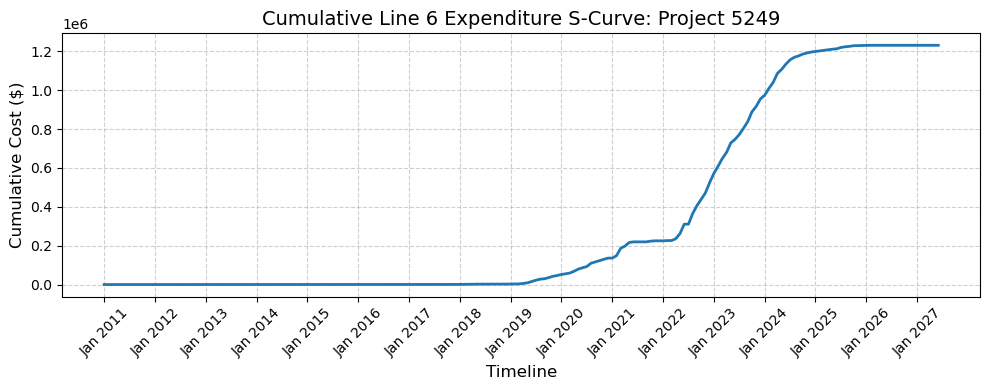

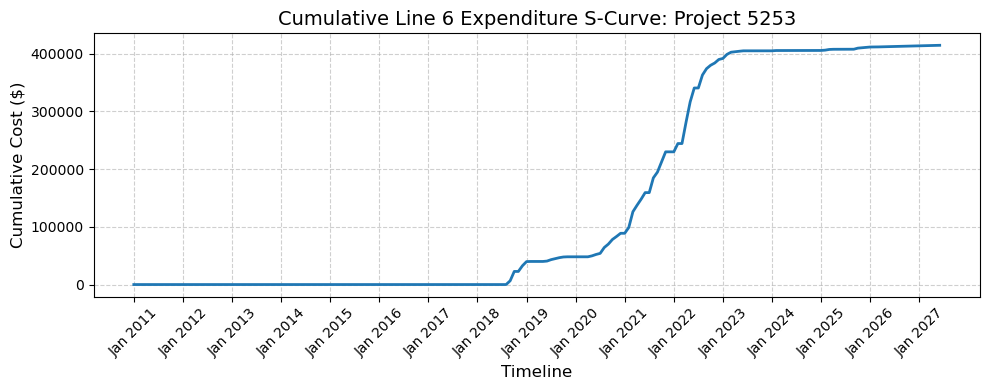

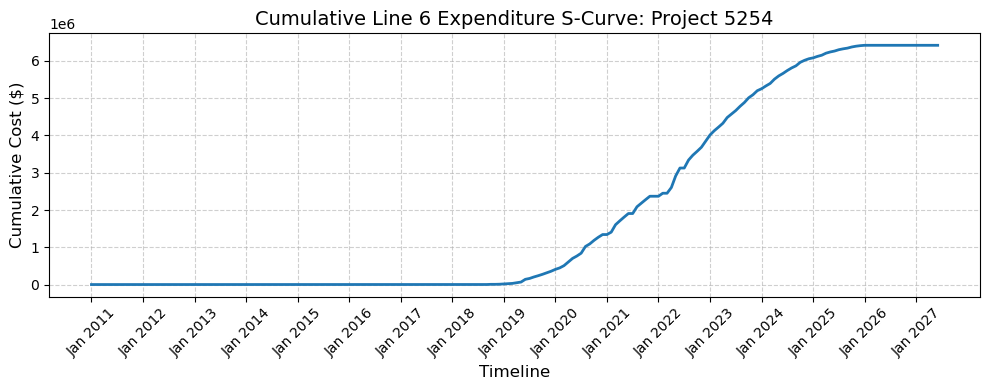

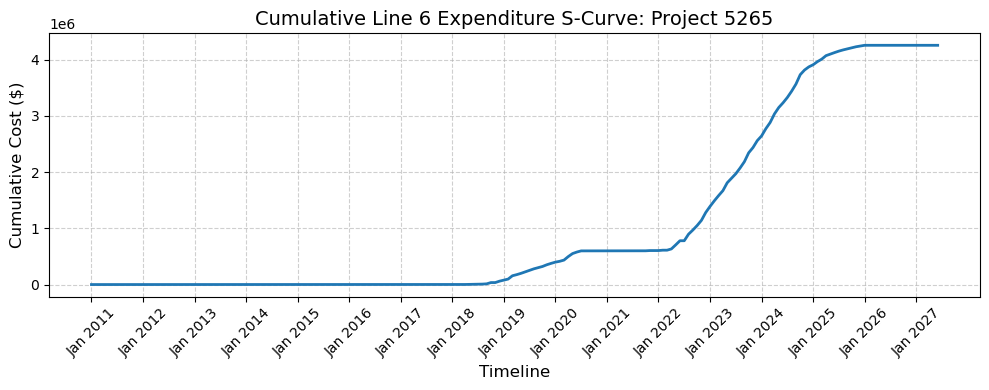

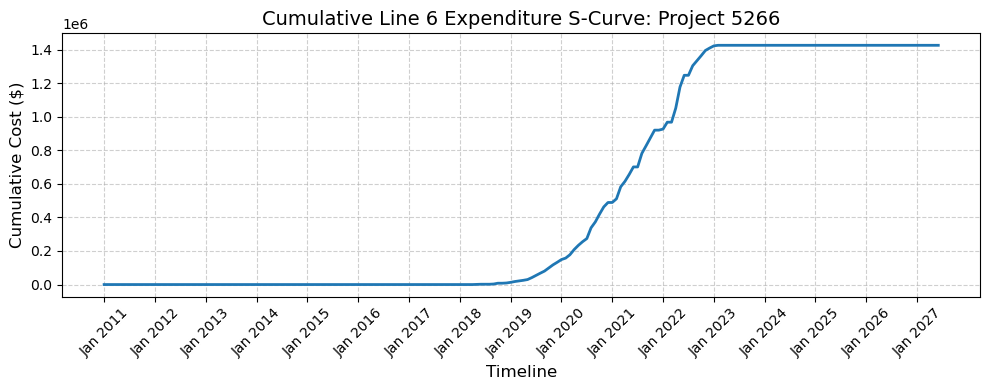

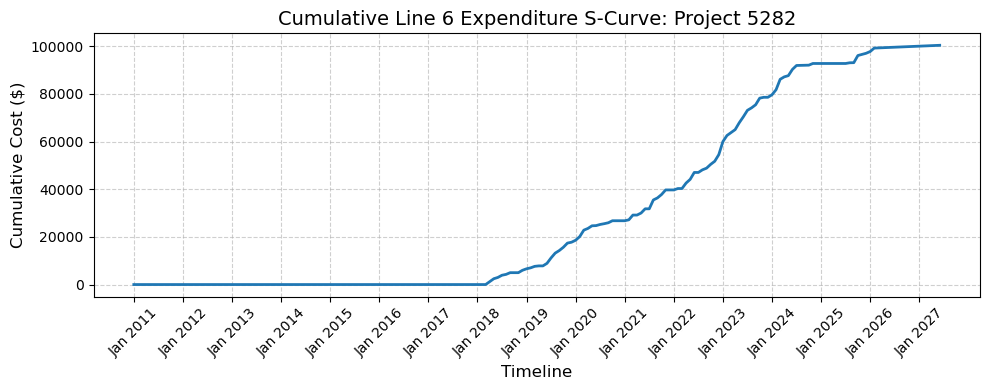

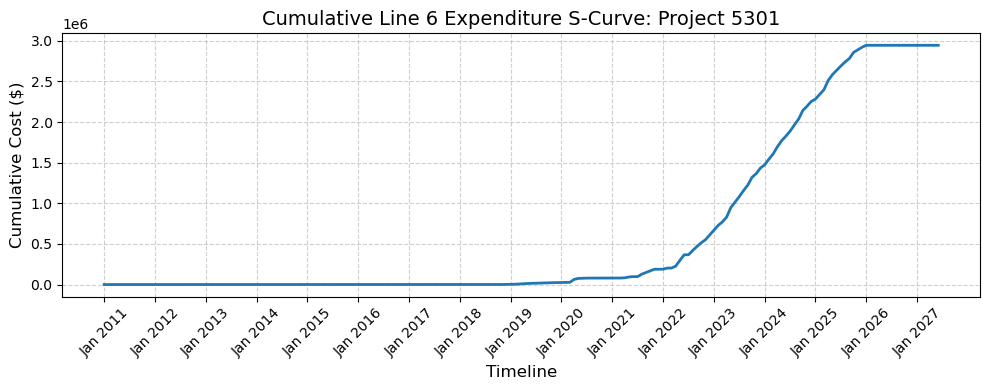

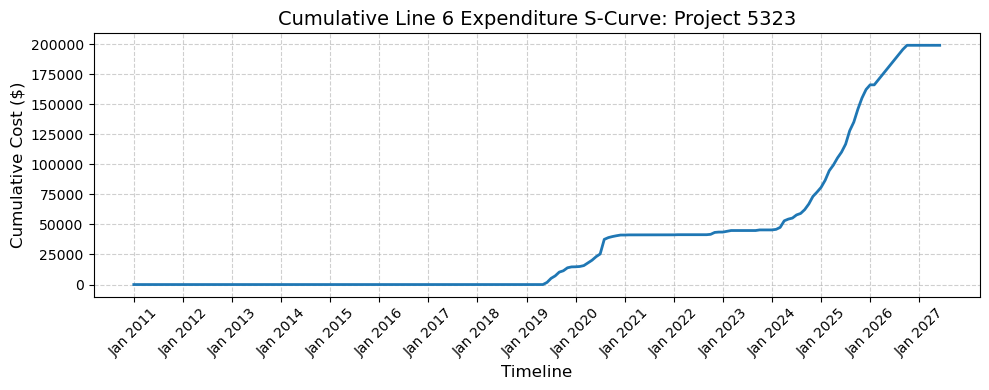

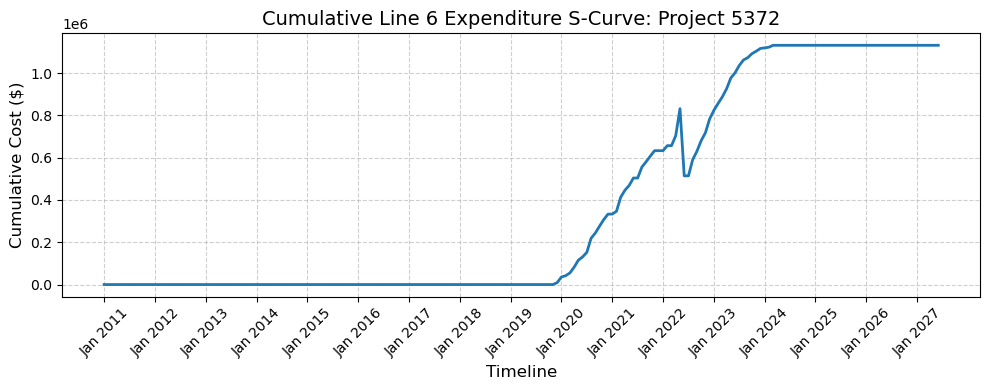

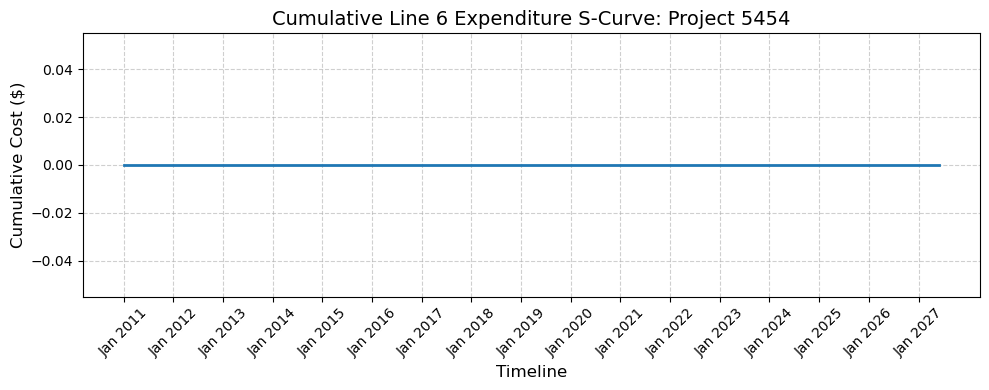

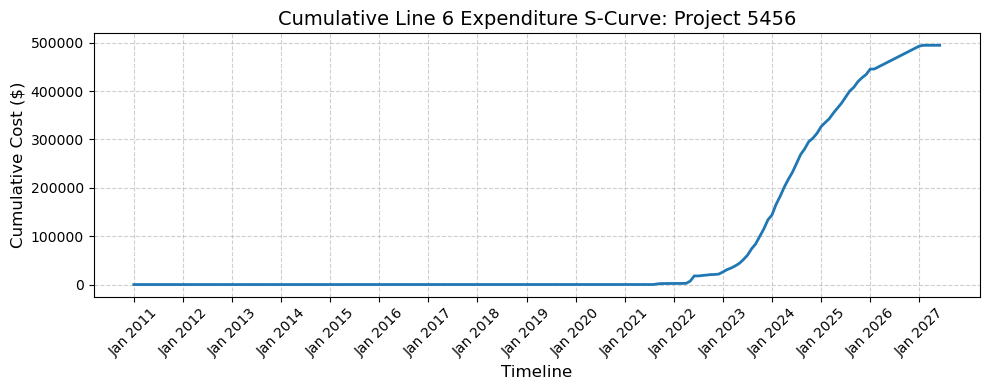

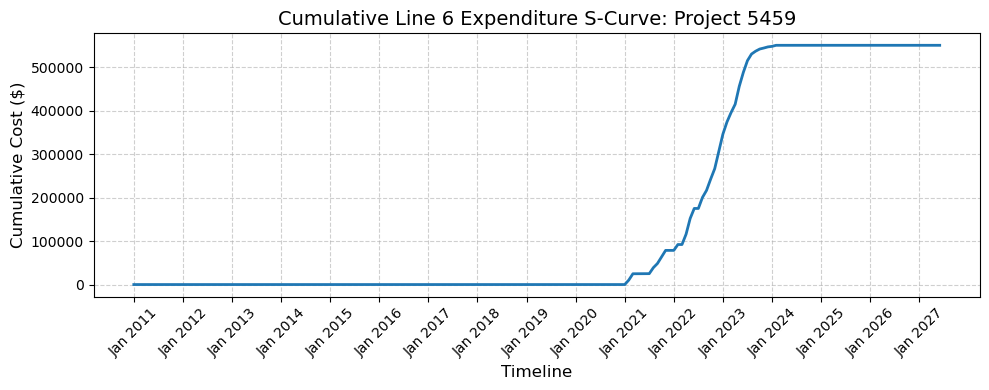

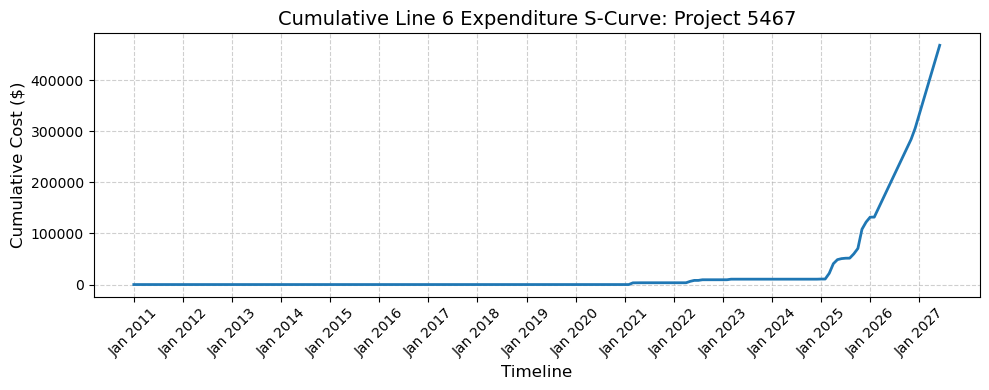

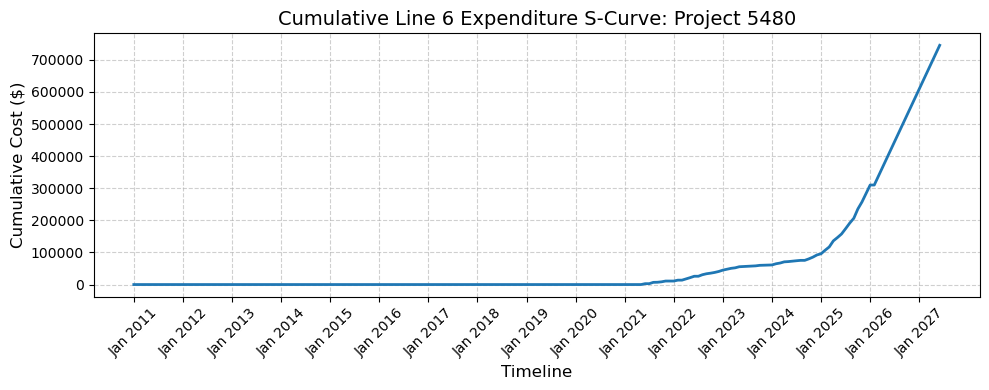

In [11]:
timeline_cols = all_projects_df.columns[5:]

# Plot first 3 S_curves using cumulative sums
for index, row in all_projects_df.head(20).iterrows():
    project_code = row['Project Code']
    cumulative_values = row[timeline_cols]
    plt.figure(figsize=(10, 4))
    plt.plot(timeline_cols, cumulative_values, linewidth=2, color='#1f77b4')
    plt.title(f"Cumulative Line 6 Expenditure S-Curve: Project {project_code}", fontsize=14)
    plt.xlabel("Timeline", fontsize=12)
    plt.ylabel("Cumulative Cost ($)", fontsize=12)
    plt.xticks(timeline_cols[::12], rotation=45) 
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.tight_layout()
    plt.show()

,Project Code,Duration_Months,S_Curve_L,S_Curve_k,S_Curve_t0,Fit_R2
3,5148,119.0,7.819377e+06,0.026668,102.828051,0.858516
13,5323,89.0,2.985600e+05,0.049598,79.996623,0.885402
33,5538,68.0,3.740404e+04,0.055694,67.191203,0.895036
0,5018,37.0,2.477655e+03,0.162535,8.285824,0.905096
30,5530,63.0,9.274418e+04,0.118885,17.413602,0.934226
14,5372,52.0,1.340616e+06,0.074858,28.817251,0.938080
28,5528,61.0,3.027795e+05,0.086059,55.466500,0.944225
48,5728,27.0,1.034405e+05,0.129124,11.340910,0.944896
31,5531,45.0,1.352580e+05,0.086359,37.480604,0.950874
39,5566,62.0,3.842512e+05,0.066426,54.858907,0.963288


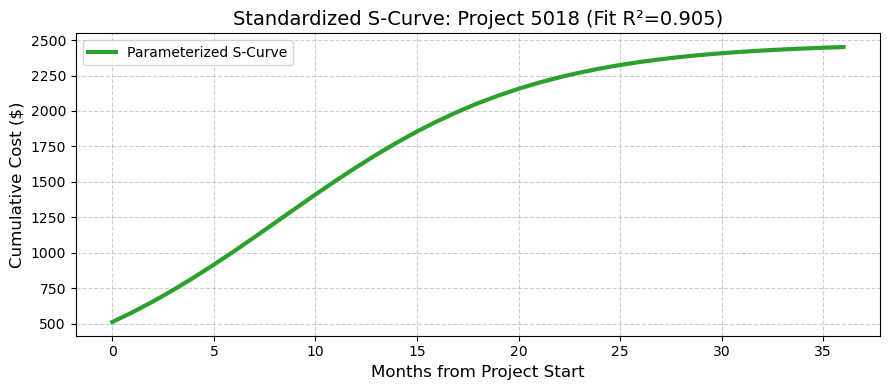

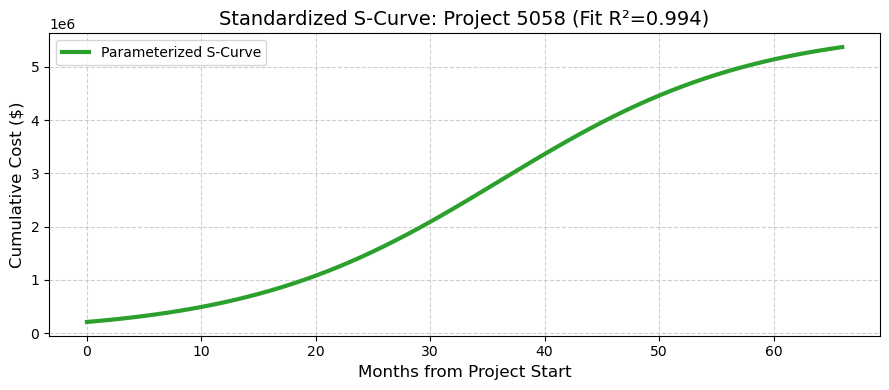

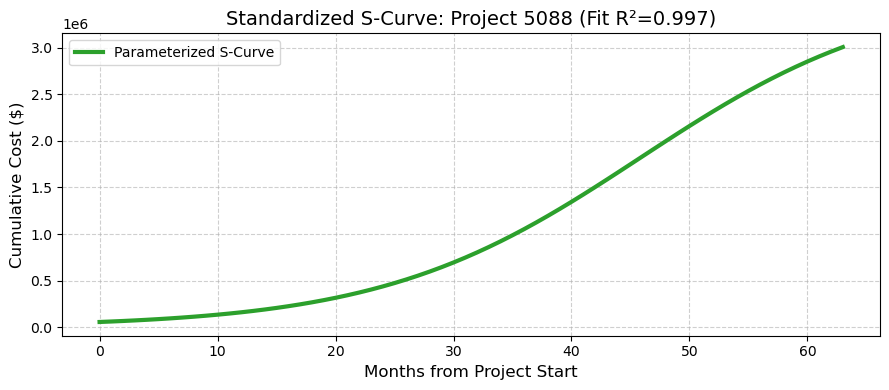

In [12]:
########################################################
"""

Extracts "Duration" (in months), "S_Curve_L" (max value), "S_Curve_k" (growth rate),
"S_Curve_t0" (midpoint) variables from the cumulative monthly spending per month.
All projects "start" in the same arbitrary place. This is what the model will actually
use.

"""
########################################################

# Define our S-curve mathematical model
def logistic_curve(t, L, k, t0):
    return L / (1 + np.exp(-k * (t - t0)))

all_projects_df_2 = all_projects_df.copy()

# Prepare timeline
timeline_dates = pd.date_range(start='2011-01-01', end='2027-06-01', freq='MS')
timeline_cols = timeline_dates.strftime('%b %Y').tolist()

L_params  = []
k_params  = []
t0_params = []
durations = []
r2_values = []

R2_THRESHOLD = 0.75

# Loop through the projects
for index, row in all_projects_df_2.iterrows():
    y_data_full = row[timeline_cols].values.astype(float)
    start_idx = np.argmax(y_data_full > 0)
    monthly_deltas = np.diff(y_data_full, prepend=0)
    nonzero_months = np.where(monthly_deltas > 0)[0]

    if len(nonzero_months) == 0:
        durations.append(np.nan)
        L_params.append(np.nan)
        k_params.append(np.nan)
        t0_params.append(np.nan)
        r2_values.append(np.nan)
        continue

    stop_idx = nonzero_months[-1]

    # Get duration
    num_months = stop_idx - start_idx + 1
    durations.append(num_months)

    # Filter for projects less than 3 months long
    if num_months < 3:
        L_params.append(np.nan)
        k_params.append(np.nan)
        t0_params.append(np.nan)
        r2_values.append(np.nan)
        continue

    y_active = y_data_full[start_idx : stop_idx + 1]
    x_active = np.arange(num_months)

    # Fit curves
    initial_guess = [y_active[-1], 0.1, num_months / 2]

    max_budget_limit = y_active[-1] * 1.5
    if max_budget_limit == 0:
        max_budget_limit = 1

    param_bounds = ([0, 0.001, 0], [max_budget_limit, 5.0, num_months])

    try:
        popt, pcov = curve_fit(logistic_curve, x_active, y_active, p0=initial_guess, bounds=param_bounds, maxfev=5000)

        # Compute R^2 for fit quality
        y_pred_fit = logistic_curve(x_active, *popt)
        ss_res = np.sum((y_active - y_pred_fit) ** 2)
        ss_tot = np.sum((y_active - np.mean(y_active)) ** 2)
        r_squared = 1 - (ss_res / ss_tot) if ss_tot > 0 else 0.0
        r2_values.append(r_squared)

        if r_squared < R2_THRESHOLD:
            print(f"  [WARN] Project {row['Project Code']}: poor logistic fit R²={r_squared:.3f}, excluding from training labels")
            L_params.append(np.nan)
            k_params.append(np.nan)
            t0_params.append(np.nan)
        else:
            L_params.append(popt[0])
            k_params.append(popt[1])
            t0_params.append(popt[2])

    except RuntimeError as e:
        print(f"  [FAIL] Project {row['Project Code']}: curve_fit failed — {e}")
        L_params.append(np.nan)
        k_params.append(np.nan)
        t0_params.append(np.nan)
        r2_values.append(np.nan)

# Save features as new columns
all_projects_df_2['Duration_Months'] = durations
all_projects_df_2['S_Curve_L']       = L_params
all_projects_df_2['S_Curve_k']       = k_params
all_projects_df_2['S_Curve_t0']      = t0_params
all_projects_df_2['Fit_R2']          = r2_values

display(all_projects_df_2[['Project Code', 'Duration_Months', 'S_Curve_L', 'S_Curve_k', 'S_Curve_t0', 'Fit_R2']].sort_values('Fit_R2'))

# Plot first 3 valid projects
plotted = 0
for index, row in all_projects_df_2.head(3).iterrows():
    L, k, t0, duration = row['S_Curve_L'], row['S_Curve_k'], row['S_Curve_t0'], row['Duration_Months']
    if pd.isna(L) or pd.isna(k) or pd.isna(t0) or pd.isna(duration):
        continue
    x_data = np.arange(int(duration))
    predicted_y = logistic_curve(x_data, L, k, t0)
    plt.figure(figsize=(9, 4))
    plt.plot(x_data, predicted_y, linewidth=3, color='#2ca02c', label="Parameterized S-Curve")
    plt.title(f"Standardized S-Curve: Project {row['Project Code']} (Fit R²={row['Fit_R2']:.3f})", fontsize=14)
    plt.xlabel("Months from Project Start", fontsize=12)
    plt.ylabel("Cumulative Cost ($)", fontsize=12)
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.legend()
    plt.tight_layout()
    plt.show()
    plotted += 1

In [13]:
timeline_dates = pd.date_range(start='2011-01-01', end='2027-06-01', freq='MS')
timeline_cols = timeline_dates.strftime('%b %Y').tolist()

# Replace timeline monthly columns with parameters
all_projects_df = all_projects_df_2.drop(columns=timeline_cols, errors='ignore')

In [14]:
# Remove projects with insufficient data (~1-2 months)
all_projects_df = all_projects_df[all_projects_df["Project Code"].astype(str) != "W5678"].reset_index(drop=True)
all_projects_df = all_projects_df[all_projects_df["Project Code"].astype(str) != "5570"].reset_index(drop=True)
all_projects_df = all_projects_df[all_projects_df["Project Code"].astype(str) != "5454"].reset_index(drop=True)
all_projects_df = all_projects_df[all_projects_df["Project Code"].astype(str) != "5538"].reset_index(drop=True)

# Convert feature values to float
all_projects_df[['Gross Sq Footage', 'Projected Budget', 'Projected Commitments', 'Estimate at Completion']] = (
    all_projects_df[['Gross Sq Footage', 'Projected Budget', 'Projected Commitments', 'Estimate at Completion']]
    .replace({'[\$,]': ''}, regex=True)
    .astype(float)
)

all_projects_df.head(60)

,Project Code,Gross Sq Footage,Projected Budget,Projected Commitments,Estimate at Completion,Duration_Months,S_Curve_L,S_Curve_k,S_Curve_t0,Fit_R2
0,5018,99812.0,2529.00,2529.00,2529.00,37.0,2.477655e+03,0.162535,8.285824,0.905096
1,5058,1441000.0,5836706.92,5224891.00,5891123.92,67.0,5.730409e+06,0.090610,36.121801,0.993837
2,5088,187000.0,4727457.00,3135281.63,4727457.00,64.0,3.635787e+06,0.091306,45.820936,0.997316
3,5148,394859.0,5212918.33,4276794.08,5625441.66,119.0,7.819377e+06,0.026668,102.828051,0.858516
4,5171,251000.0,8881281.25,8528407.75,9234154.75,107.0,9.325912e+06,0.056329,68.996787,0.995134
5,5199,7500.0,723162.28,517011.75,723162.28,95.0,6.019694e+05,0.063102,60.360025,0.991103
6,5249,16400.0,1243997.75,1230939.50,1244438.75,98.0,1.322774e+06,0.100906,63.376751,0.993151
7,5253,NaN,416000.00,414043.50,420993.00,106.0,4.156630e+05,0.133045,36.143164,0.989887
8,5254,1432052.0,6700000.00,6409380.75,6700000.00,94.0,6.673823e+06,0.078574,51.857231,0.997271
9,5265,580500.0,4302000.00,4239862.25,4302000.00,94.0,5.349084e+06,0.073365,69.562480,0.984253


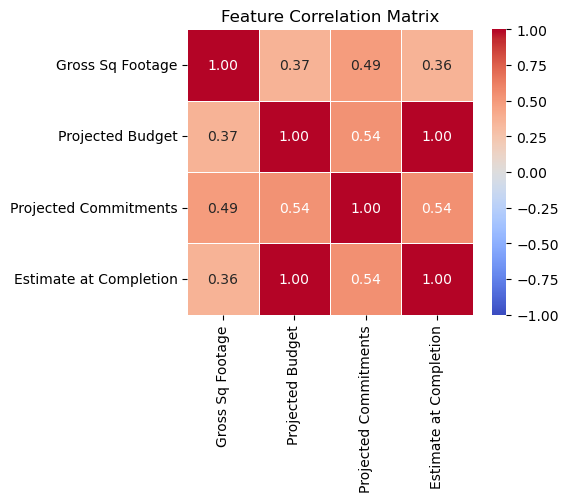

In [15]:
import seaborn as sns

feature_cols = ['Gross Sq Footage', 'Projected Budget', 'Projected Commitments', 'Estimate at Completion']

# Create feature inter-correlation matrix
corr = all_projects_df[feature_cols].corr()
plt.figure(figsize=(6, 5))
sns.heatmap(corr, annot=True, fmt=".2f", cmap='coolwarm', vmin=-1, vmax=1, square=True, linewidths=0.5)
plt.title("Feature Correlation Matrix")
plt.tight_layout()
plt.show()


Estimate at Completion and Projected Budget show perfect correlation here, but they're not EXACTLY identical - only a small negligible difference. I'm choosing to leave them in with the thought that this nuance helps.

In [16]:
# Add new features EAC Budget Ratio and Commitments Budget Ratio (financial health independent of project size)
all_projects_df['EAC_Budget_Ratio'] = (all_projects_df['Estimate at Completion'] / all_projects_df['Projected Budget'].replace(0, np.nan))
all_projects_df['Commitments_Budget_Ratio'] = (all_projects_df['Projected Commitments'] / all_projects_df['Projected Budget'].replace(0, np.nan))

# Remove more NANs
mean_sq_footage = all_projects_df['Gross Sq Footage'].mean()
all_projects_df['Gross Sq Footage'] = all_projects_df['Gross Sq Footage'].fillna(mean_sq_footage)

# Update feature list
feature_cols = [
    'Gross Sq Footage', 'Projected Budget', 'Projected Commitments',
    'Estimate at Completion', 'EAC_Budget_Ratio', 'Commitments_Budget_Ratio'
]

display(all_projects_df.head(100))

,Project Code,Gross Sq Footage,Projected Budget,Projected Commitments,Estimate at Completion,Duration_Months,S_Curve_L,S_Curve_k,S_Curve_t0,Fit_R2,EAC_Budget_Ratio,Commitments_Budget_Ratio
0,5018,9.981200e+04,2529.00,2529.00,2529.00,37.0,2.477655e+03,0.162535,8.285824,0.905096,1.000000,1.000000
1,5058,1.441000e+06,5836706.92,5224891.00,5891123.92,67.0,5.730409e+06,0.090610,36.121801,0.993837,1.009323,0.895178
2,5088,1.870000e+05,4727457.00,3135281.63,4727457.00,64.0,3.635787e+06,0.091306,45.820936,0.997316,1.000000,0.663207
3,5148,3.948590e+05,5212918.33,4276794.08,5625441.66,119.0,7.819377e+06,0.026668,102.828051,0.858516,1.079135,0.820422
4,5171,2.510000e+05,8881281.25,8528407.75,9234154.75,107.0,9.325912e+06,0.056329,68.996787,0.995134,1.039732,0.960268
5,5199,7.500000e+03,723162.28,517011.75,723162.28,95.0,6.019694e+05,0.063102,60.360025,0.991103,1.000000,0.714932
6,5249,1.640000e+04,1243997.75,1230939.50,1244438.75,98.0,1.322774e+06,0.100906,63.376751,0.993151,1.000355,0.989503
7,5253,2.454154e+05,416000.00,414043.50,420993.00,106.0,4.156630e+05,0.133045,36.143164,0.989887,1.012002,0.995297
8,5254,1.432052e+06,6700000.00,6409380.75,6700000.00,94.0,6.673823e+06,0.078574,51.857231,0.997271,1.000000,0.956624
9,5265,5.805000e+05,4302000.00,4239862.25,4302000.00,94.0,5.349084e+06,0.073365,69.562480,0.984253,1.000000,0.985556


In [17]:
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.model_selection import LeaveOneOut, cross_val_predict, GridSearchCV
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error


In [18]:
########################################################
"""

LOO CROSS-VALIDATION FOR EACH TARGET: Duration_Months, S_Curve_L, S_Curve_k, S_Curve_t0
GridSearchCV finds best RF hyperparameters once on the full dataset, cross_val_predict
then generates out-of-fold predictions via LOO. 

Trains both a RandomForest and GradientBoostingRegressor and takes the better of the 2.

"""
########################################################

X = all_projects_df[feature_cols]
targets = {'Duration_Months': all_projects_df['Duration_Months'], 'S_Curve_L': all_projects_df['S_Curve_L'], 'S_Curve_k': all_projects_df['S_Curve_k'], 'S_Curve_t0': all_projects_df['S_Curve_t0']}

loo = LeaveOneOut()
best_models    = {}
loo_predictions = {}

param_grid = {'n_estimators': [100, 200], 'max_depth': [5, 10, 15, None], 'min_samples_split': [2, 5, 10], 'min_samples_leaf':  [1, 2, 4], 'max_features':    ['sqrt', 'log2', 1.0]}

for target_name, y in targets.items():
    print(f"\n{'='*55}")
    print(f"  TARGET: {target_name}")
    print(f"{'='*55}")

    # Random Forest
    print("\n[Random Forest]")
    gs = GridSearchCV(RandomForestRegressor(), param_grid, cv=5, scoring='neg_root_mean_squared_error', n_jobs=-1)
    gs.fit(X, y)
    best_rf = gs.best_estimator_
    print(f"  Best params: {gs.best_params_}")

    y_pred_rf = cross_val_predict(best_rf, X, y, cv=loo)
    rf_rmse = np.sqrt(mean_squared_error(y, y_pred_rf))
    rf_mae  = mean_absolute_error(y, y_pred_rf)
    rf_r2   = r2_score(y, y_pred_rf)
    print(f"  LOO RMSE: {rf_rmse:.4f}  |  MAE: {rf_mae:.4f}  |  R²: {rf_r2:.4f}")

    # Feature importance for RF
    best_rf.fit(X, y)
    importances = pd.Series(best_rf.feature_importances_, index=feature_cols).sort_values()

    # Gradient Boosting
    print("\n[Gradient Boosting]")
    gb = GradientBoostingRegressor(n_estimators=200, max_depth=3, learning_rate=0.05, min_samples_leaf=2)
    y_pred_gb = cross_val_predict(gb, X, y, cv=loo)
    gb_rmse = np.sqrt(mean_squared_error(y, y_pred_gb))
    gb_r2   = r2_score(y, y_pred_gb)
    print(f"  LOO RMSE: {gb_rmse:.4f}  |  R²: {gb_r2:.4f}")

    # Use the better model
    if gb_r2 > rf_r2:
        print(f"  -> GBR wins (R² {gb_r2:.4f} vs RF {rf_r2:.4f})")
        gb.fit(X, y)
        best_models[target_name]    = gb
        loo_predictions[target_name] = y_pred_gb
    else:
        print(f"  -> RF wins (R² {rf_r2:.4f} vs GBR {gb_r2:.4f})")
        best_models[target_name]    = best_rf   # already refit above
        loo_predictions[target_name] = y_pred_rf

predictions1 = loo_predictions['Duration_Months']
predictions2 = loo_predictions['S_Curve_L']
predictions3 = loo_predictions['S_Curve_k']
predictions4 = loo_predictions['S_Curve_t0']


  TARGET: Duration_Months

[Random Forest]
  Best params: {'max_depth': 5, 'max_features': 'sqrt', 'min_samples_leaf': 2, 'min_samples_split': 2, 'n_estimators': 200}
  LOO RMSE: 23.5138  |  MAE: 19.5043  |  R²: -0.0186

[Gradient Boosting]
  LOO RMSE: 27.8379  |  R²: -0.4276
  -> RF wins (R² -0.0186 vs GBR -0.4276)

  TARGET: S_Curve_L

[Random Forest]
  Best params: {'max_depth': 10, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 200}
  LOO RMSE: 902631.8516  |  MAE: 394544.5297  |  R²: 0.8857

[Gradient Boosting]
  LOO RMSE: 1231800.1642  |  R²: 0.7871
  -> RF wins (R² 0.8857 vs GBR 0.7871)

  TARGET: S_Curve_k

[Random Forest]
  Best params: {'max_depth': 15, 'max_features': 'sqrt', 'min_samples_leaf': 4, 'min_samples_split': 10, 'n_estimators': 100}
  LOO RMSE: 0.2267  |  MAE: 0.0869  |  R²: -0.0840

[Gradient Boosting]
  LOO RMSE: 0.2678  |  R²: -0.5127
  -> RF wins (R² -0.0840 vs GBR -0.5127)

  TARGET: S_Curve_t0

[Random Forest]
  Best 

With train/test/split Random State 99 = predicting on indices: 25, 36, 29, 22, 28, 31, 26, 13
Which are project codes: 5540, 5659, 5570, 5530, 5566, 5583, 5551, 5456



In [19]:
# Build predictions DataFrame
predictions_df = pd.DataFrame({
    "Project Code": all_projects_df['Project Code'].values,
    "Duration_Months": predictions1, "S_Curve_L": predictions2, "S_Curve_k": predictions3, "S_Curve_t0": predictions4
    })

# Replace "S_Curve_L" predictions with "Projected Commitments" data
predictions_df["S_Curve_L"] = all_projects_df["Projected Commitments"]

print("Predictions DataFrame (LOO out-of-fold, all projects):")
display(predictions_df)

Predictions DataFrame (LOO out-of-fold, all projects):


,Project Code,Duration_Months,S_Curve_L,S_Curve_k,S_Curve_t0
0,5018,47.507845,2529.00,0.274839,14.966011
1,5058,91.002444,5224891.00,0.082330,58.167981
2,5088,77.441796,3135281.63,0.082744,61.076395
3,5148,72.259971,4276794.08,0.136735,48.540714
4,5171,82.475044,8528407.75,0.115294,54.658112
5,5199,49.591497,517011.75,0.129763,30.218513
6,5249,58.515543,1230939.50,0.114795,37.761338
7,5253,49.817515,414043.50,0.155010,30.596311
8,5254,77.037547,6409380.75,0.086838,48.547688
9,5265,85.221448,4239862.25,0.089345,58.832638


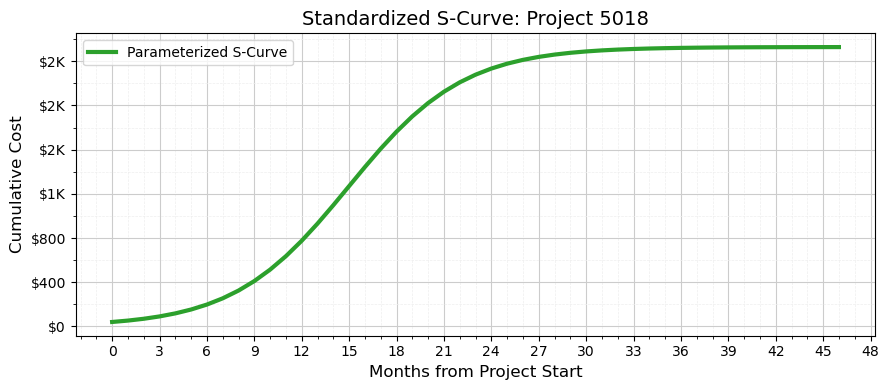

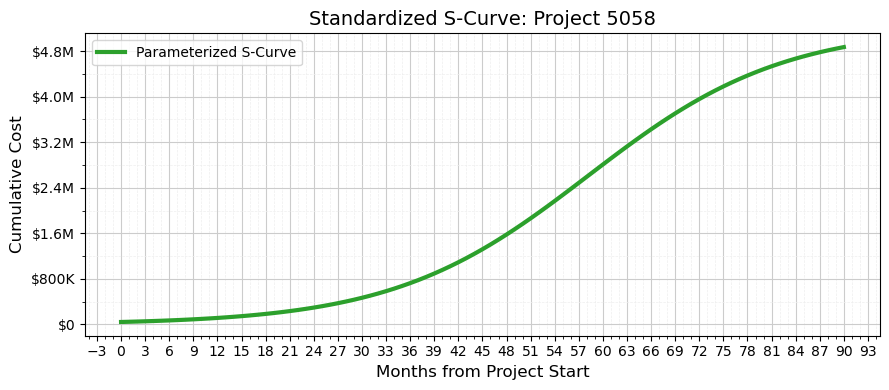

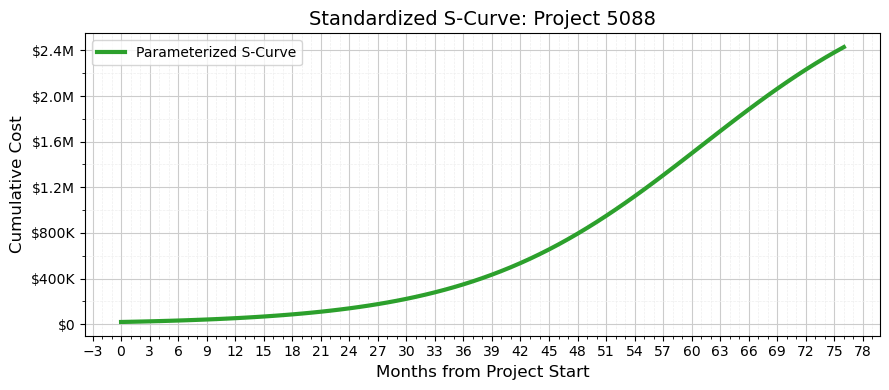

In [20]:
from matplotlib.ticker import MultipleLocator, FuncFormatter

# Currency formatter
def format_currency(x, pos):
    if x >= 1e6:
        return f'${x * 1e-6:.1f}M'
    elif x >= 1e3:
        return f'${x * 1e-3:.0f}K'
    else:
        return f'${x:,.0f}'

# Loop through and plot projects
for index, row in predictions_df.head(3).iterrows():
    L = row['S_Curve_L']
    k = row['S_Curve_k']
    t0 = row['S_Curve_t0']
    duration = row['Duration_Months']
    
    # Generate X axis
    x_data = np.arange(int(duration))
    predicted_y = logistic_curve(x_data, L, k, t0)
    
    # Plot the curve
    plt.figure(figsize=(9, 4))
    plt.plot(x_data, predicted_y, linewidth=3, color='#2ca02c', label="Parameterized S-Curve")
    plt.title(f"Standardized S-Curve: Project {row['Project Code']}", fontsize=14)
    plt.xlabel("Months from Project Start", fontsize=12) 
    plt.ylabel("Cumulative Cost", fontsize=12) # Removed ($) since the formatter adds it
    
    ax = plt.gca() 
    
    # X-Axis: Major ticks every 3 months, minor ticks every 1 month
    ax.xaxis.set_major_locator(MultipleLocator(3))
    ax.xaxis.set_minor_locator(MultipleLocator(1))
    
    # Y-Axis: Format as currency, create ~8 even major tick slices
    ax.yaxis.set_major_formatter(FuncFormatter(format_currency))
    ax.yaxis.set_major_locator(plt.MaxNLocator(8)) 
    ax.yaxis.set_minor_locator(plt.MaxNLocator(16)) 
    
    # Update grid to show both major (solid) and minor (dashed) lines
    plt.grid(which='major', color='#CCCCCC', linestyle='-', linewidth=0.8)
    plt.grid(which='minor', color='#EEEEEE', linestyle='--', linewidth=0.5)
    
    plt.legend()
    plt.tight_layout()
    plt.show()

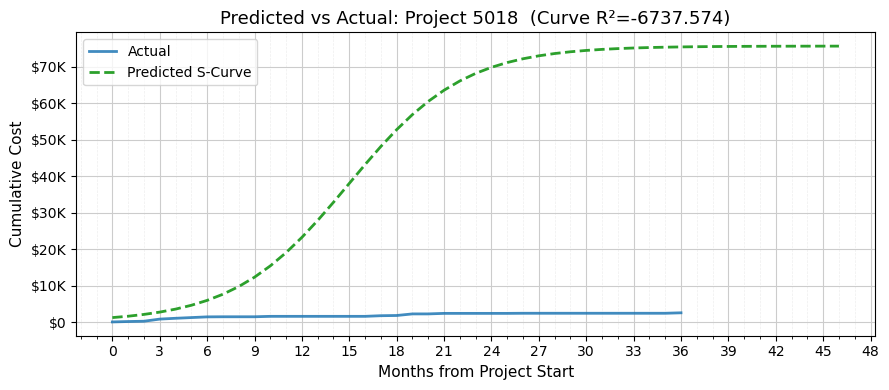

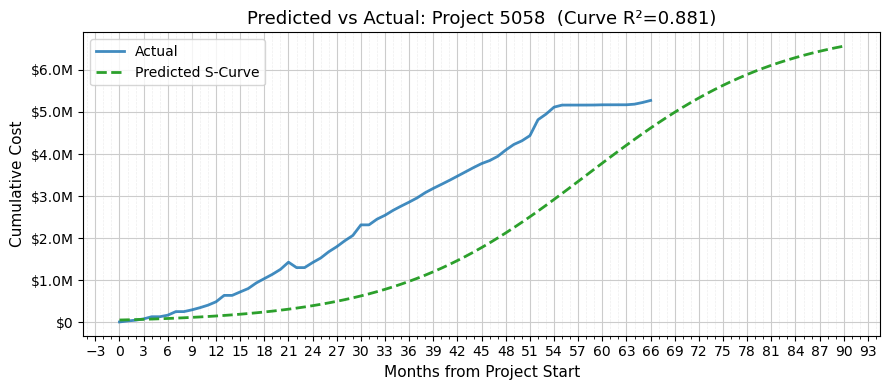

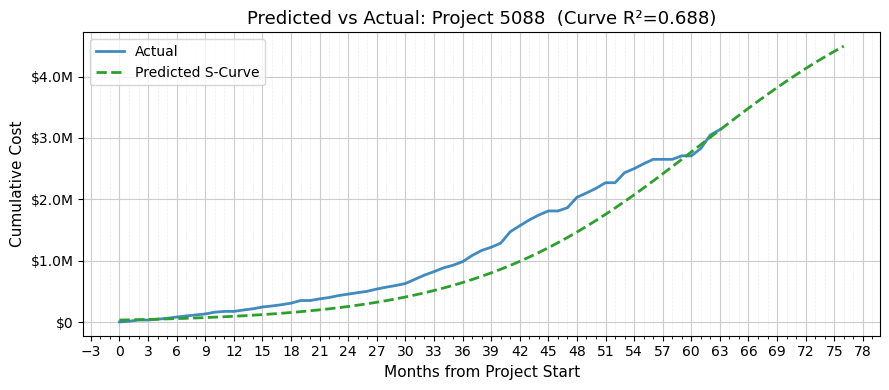

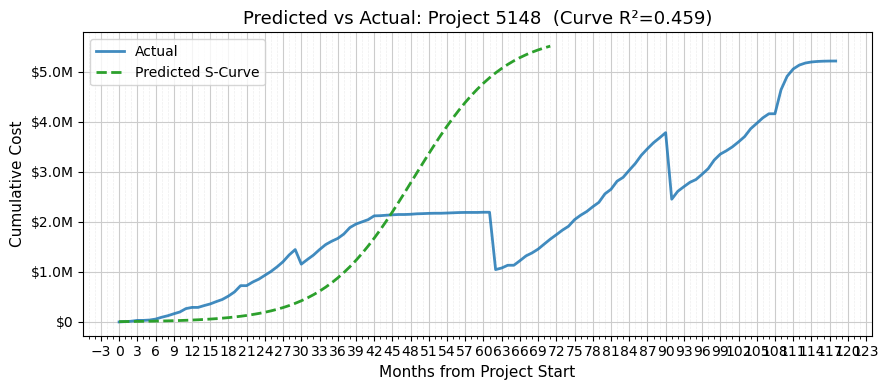

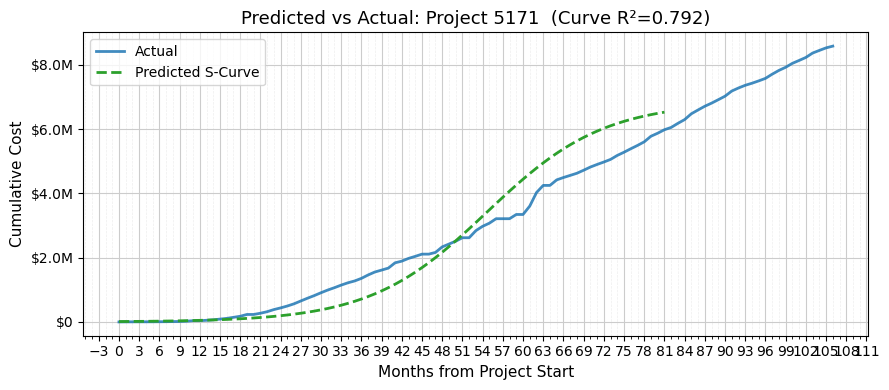

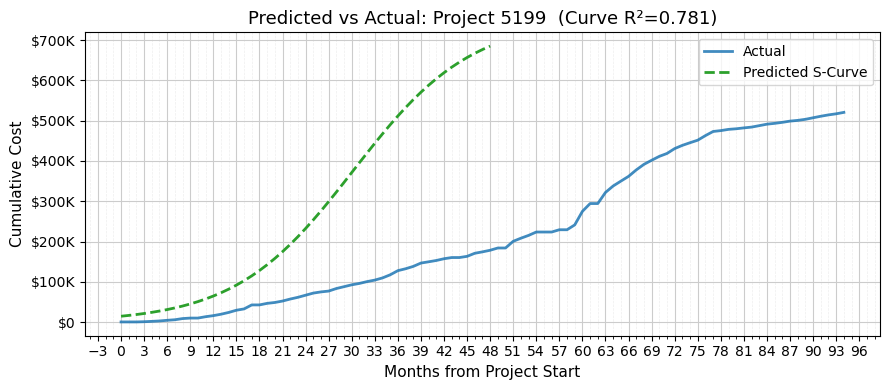

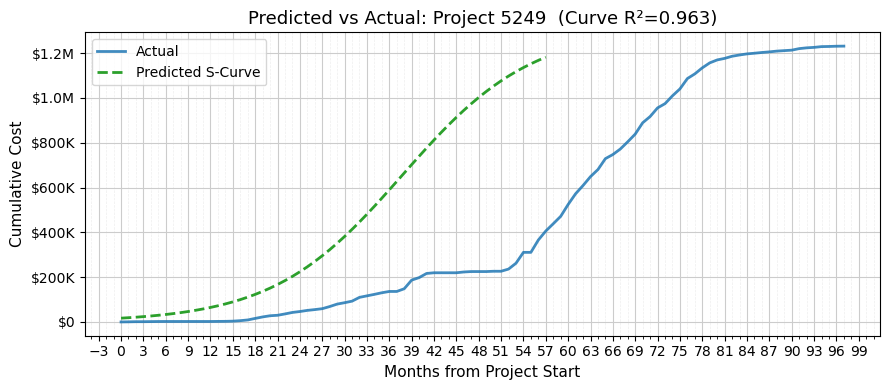

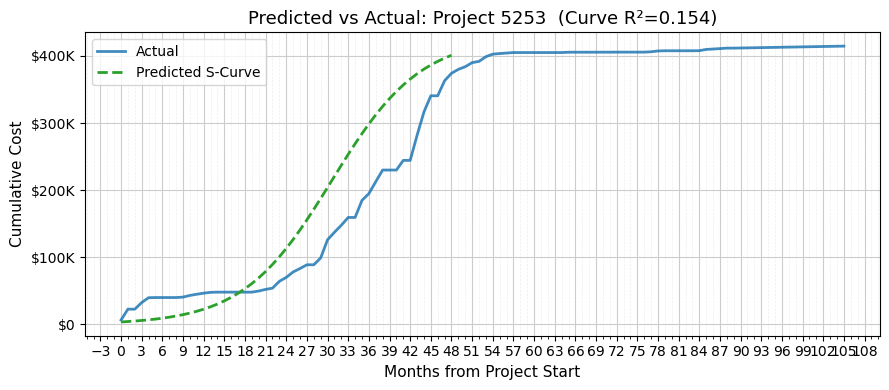

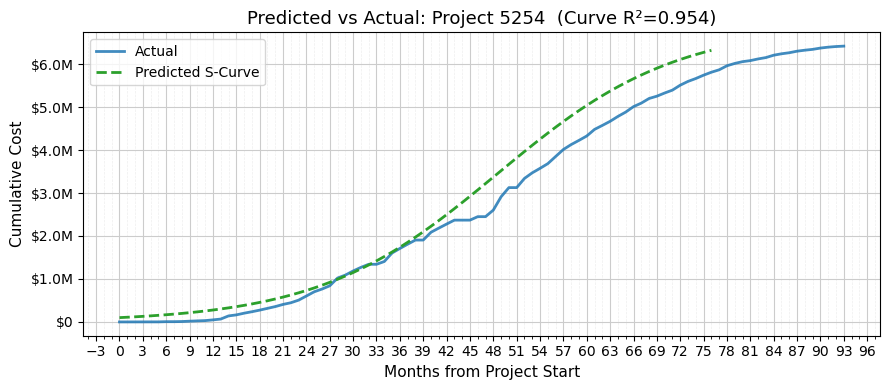

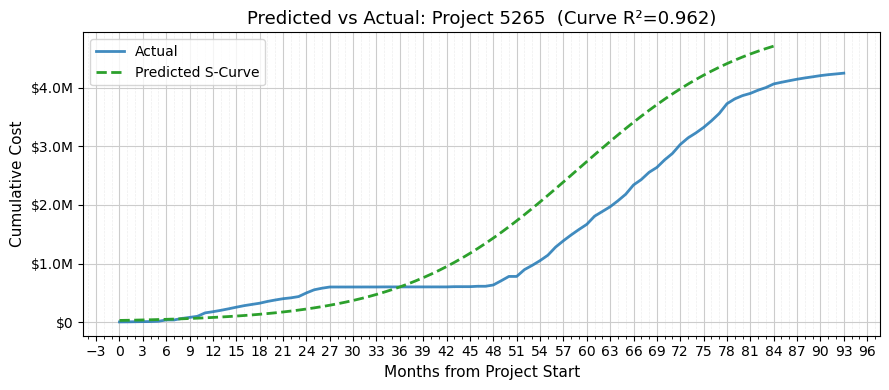

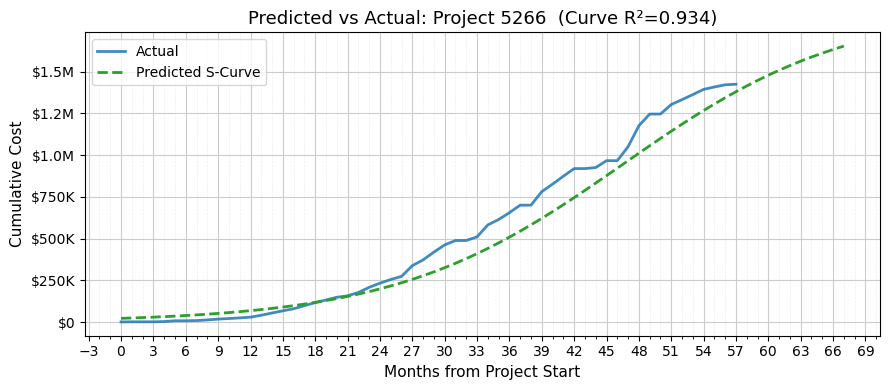

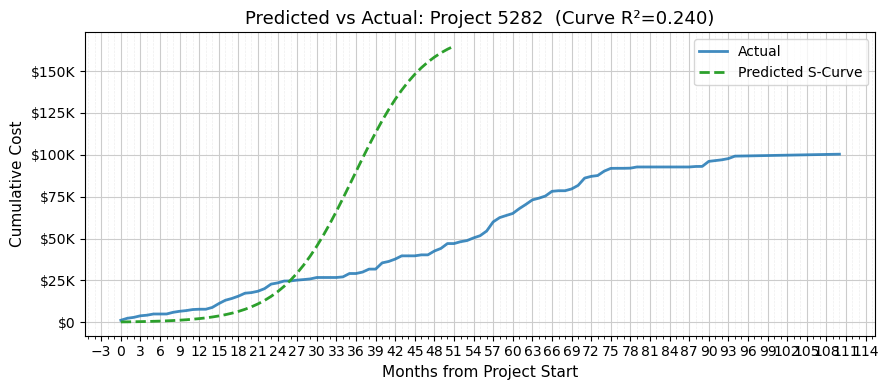

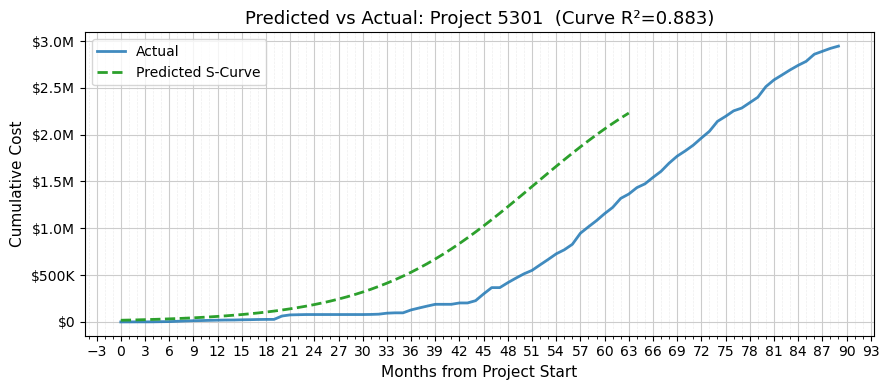

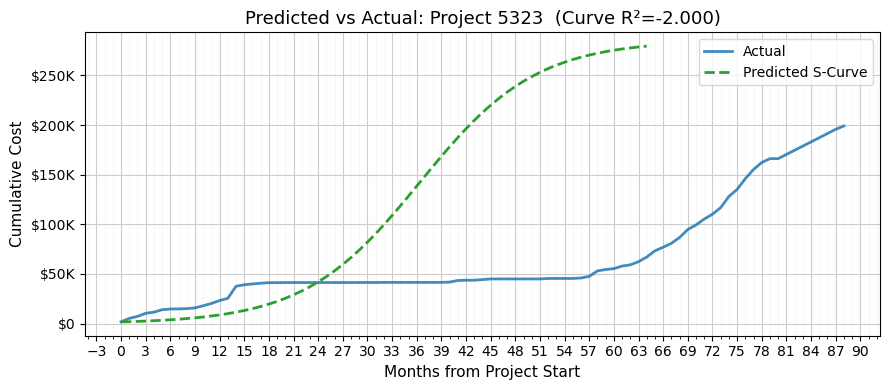

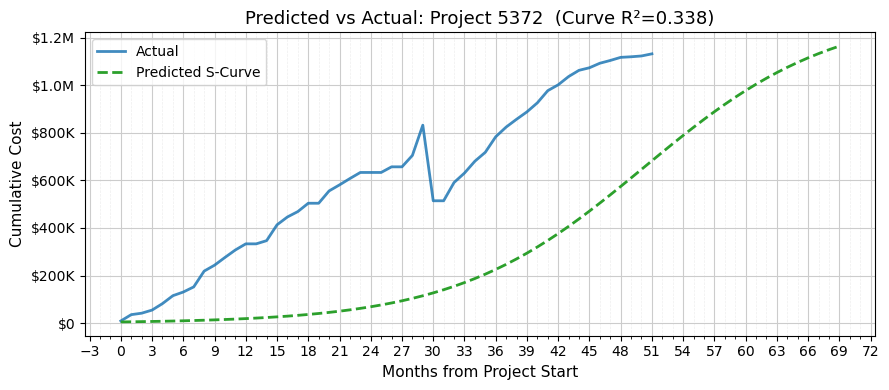

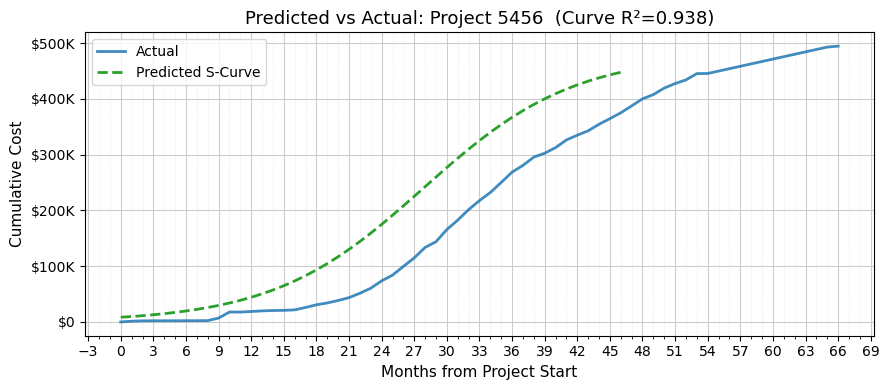

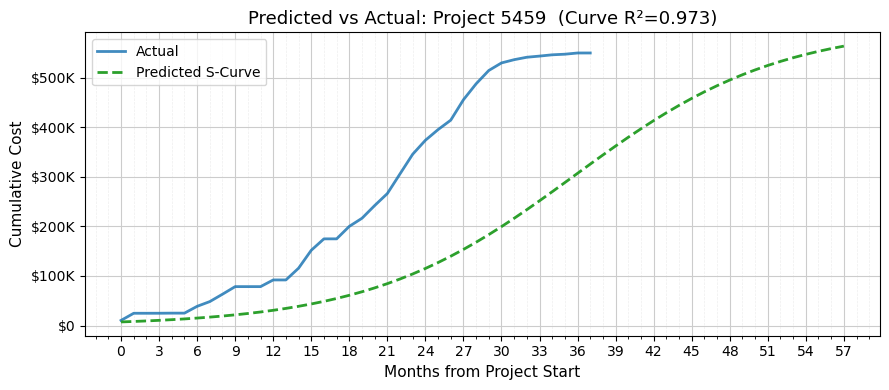

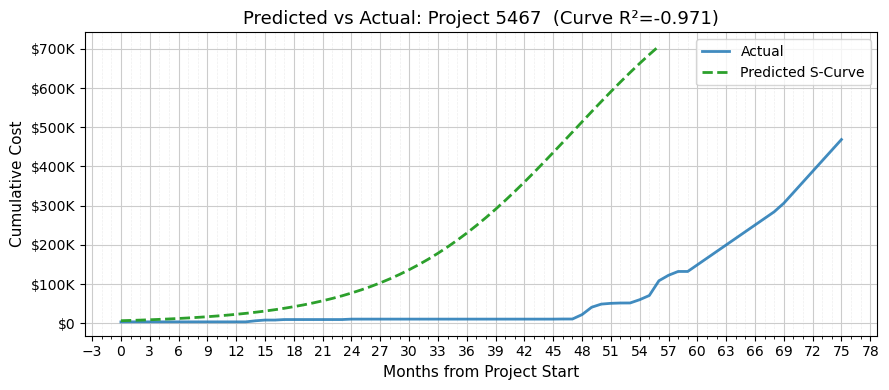

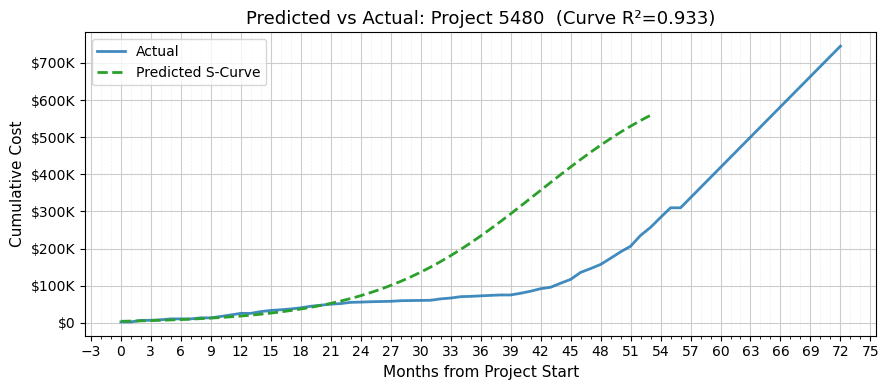

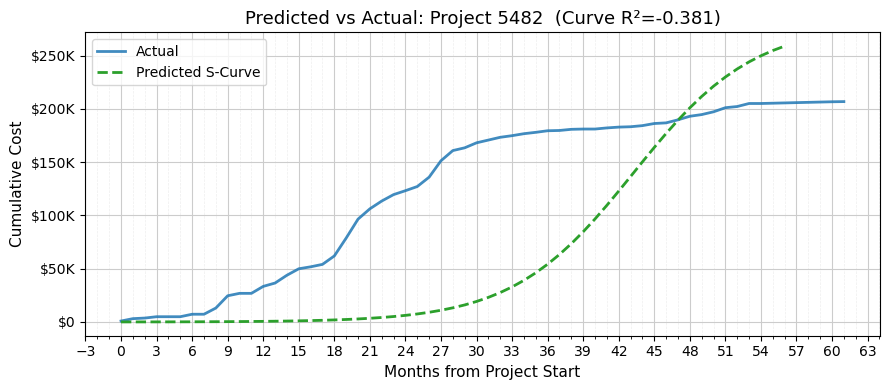

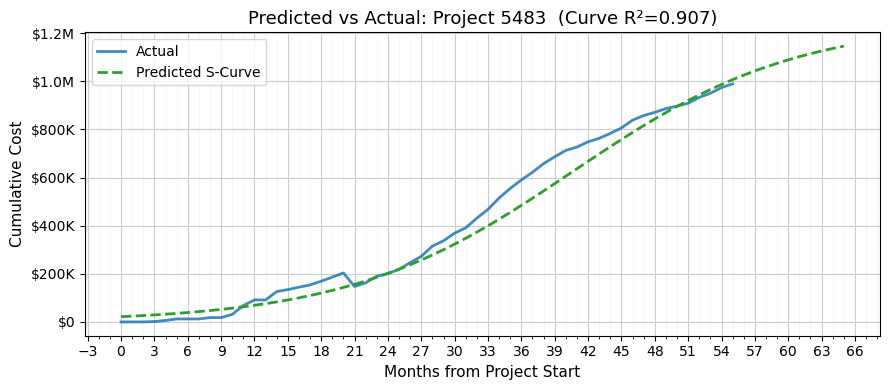

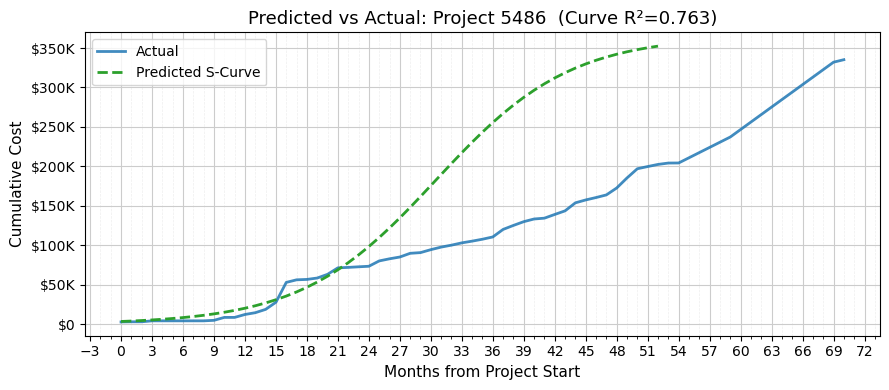

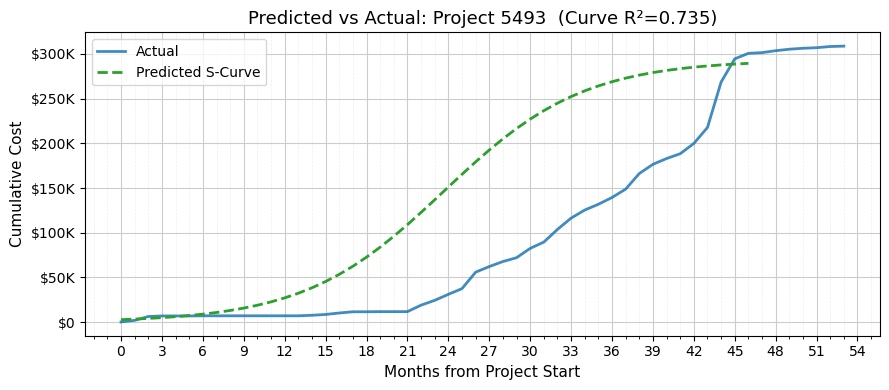

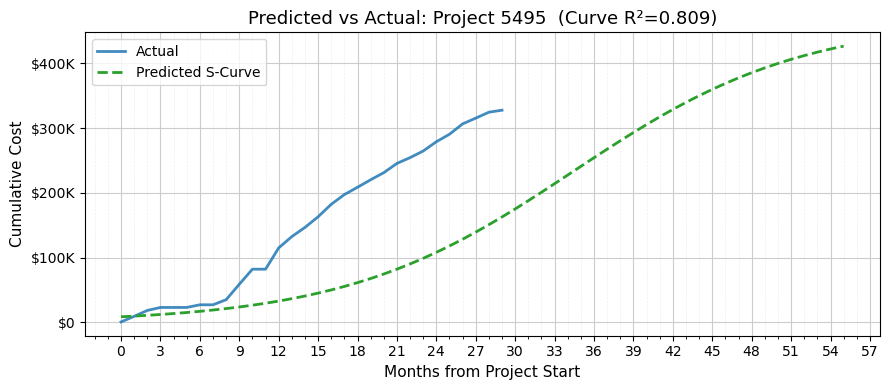

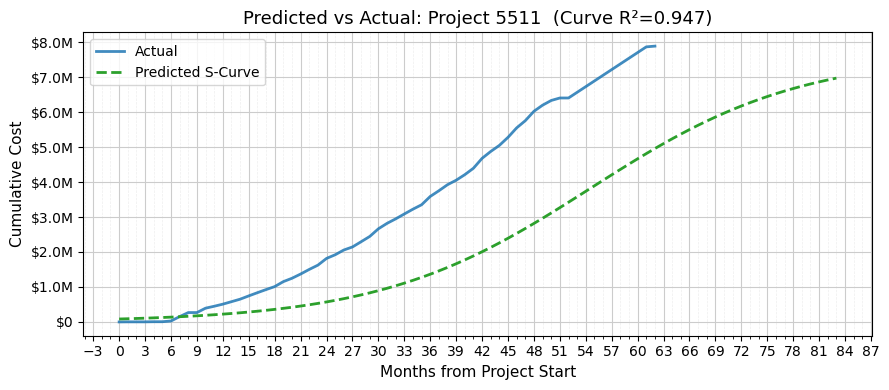

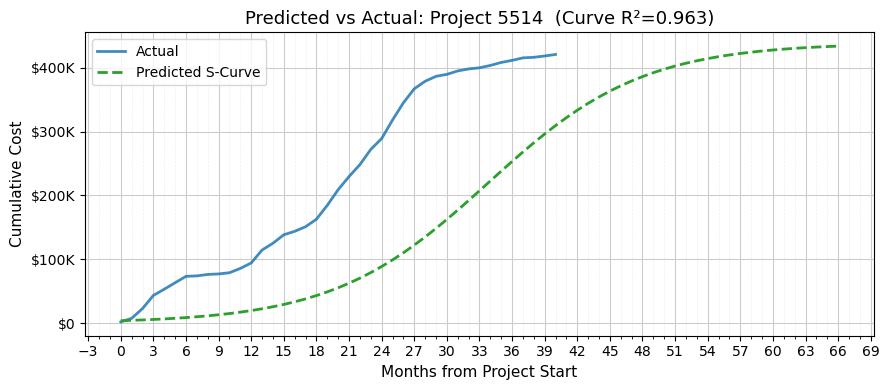

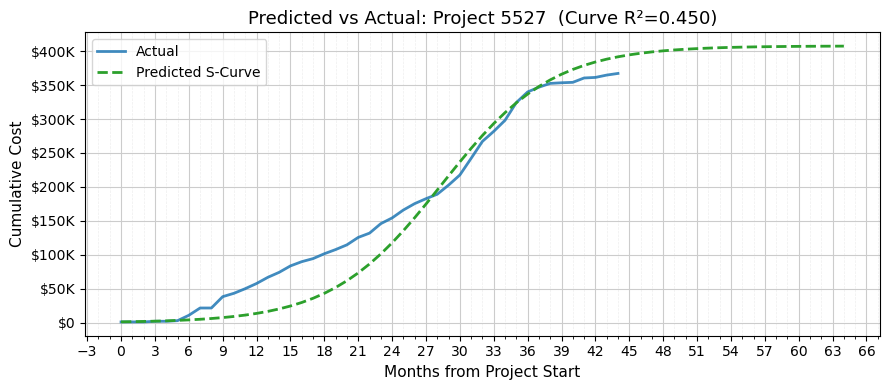

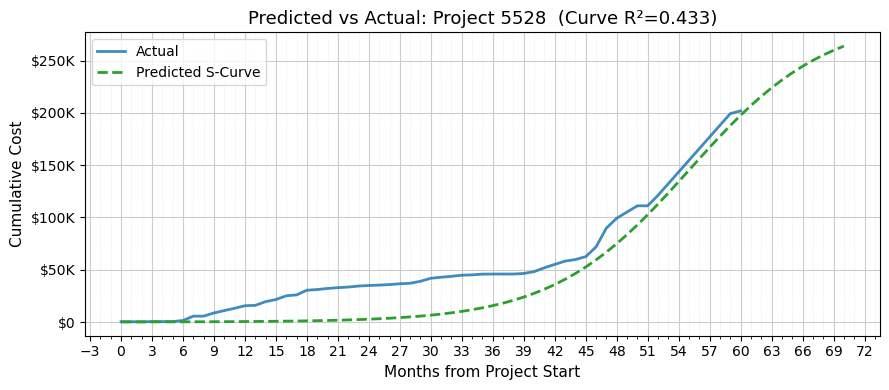

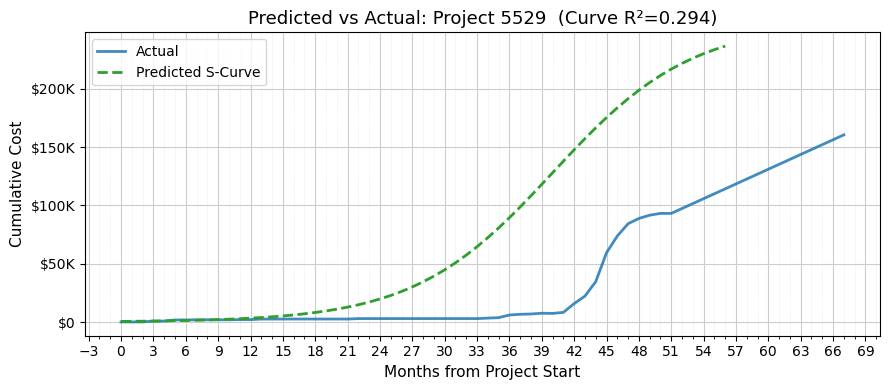

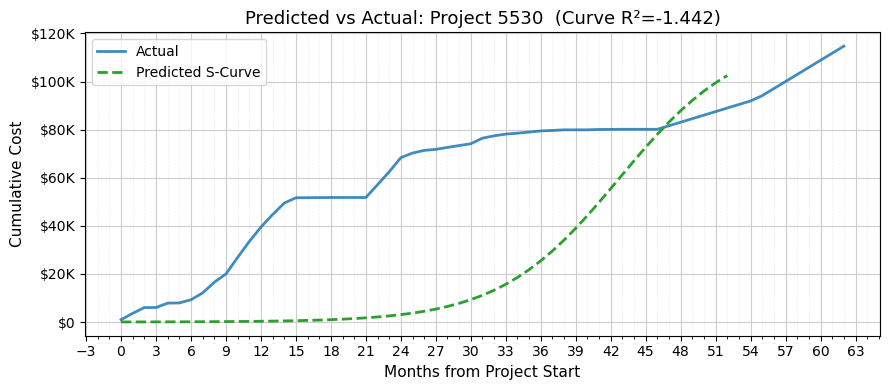

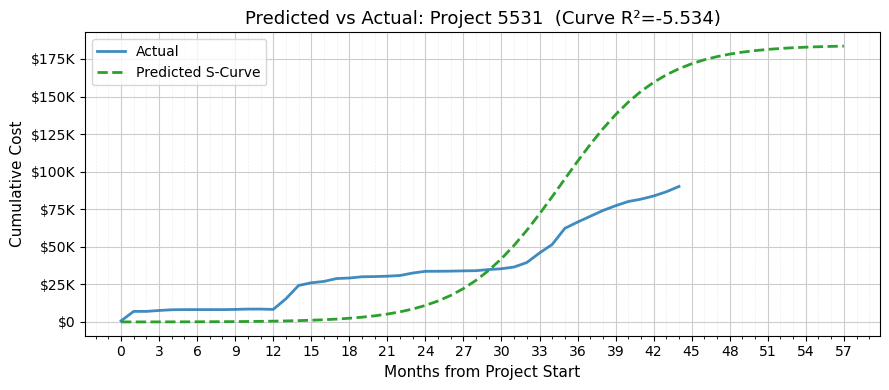

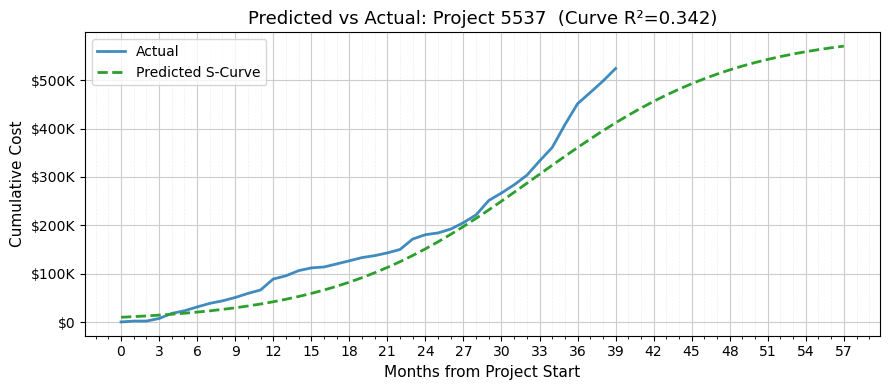

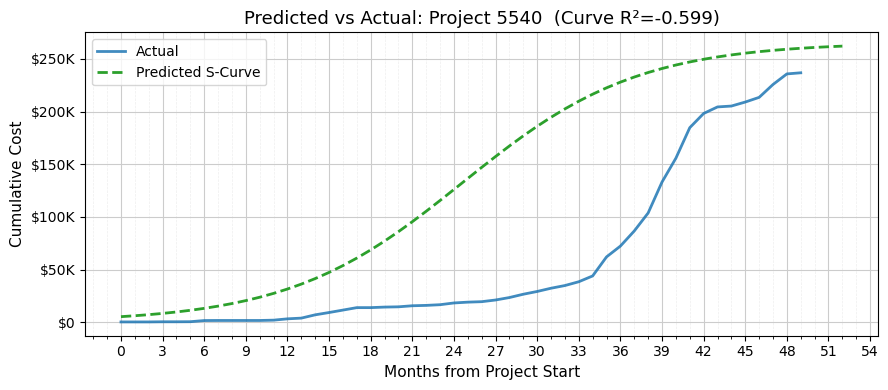

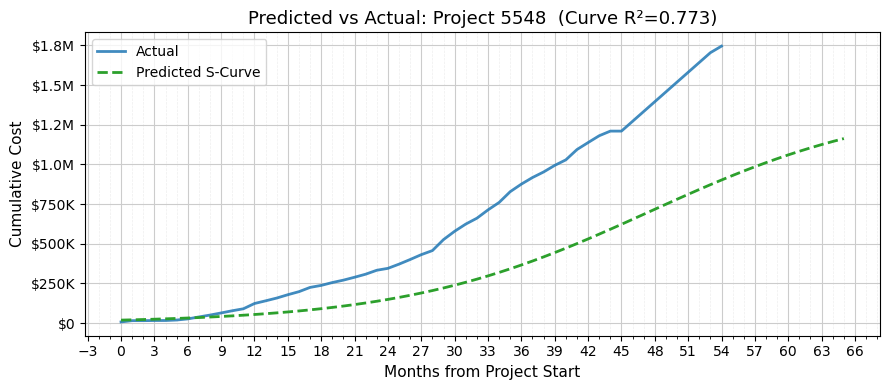

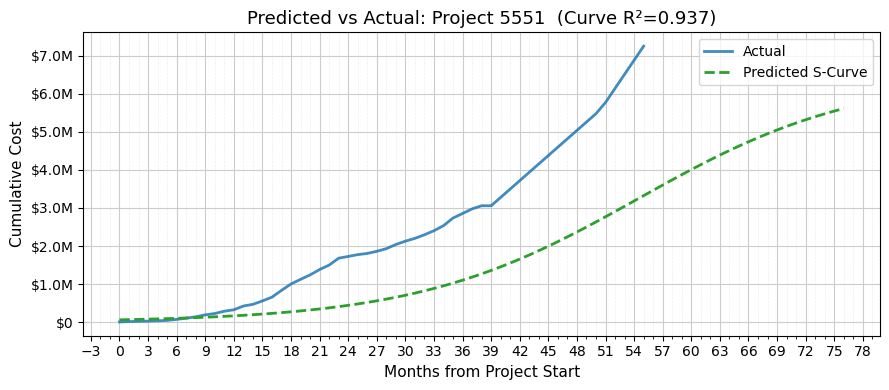

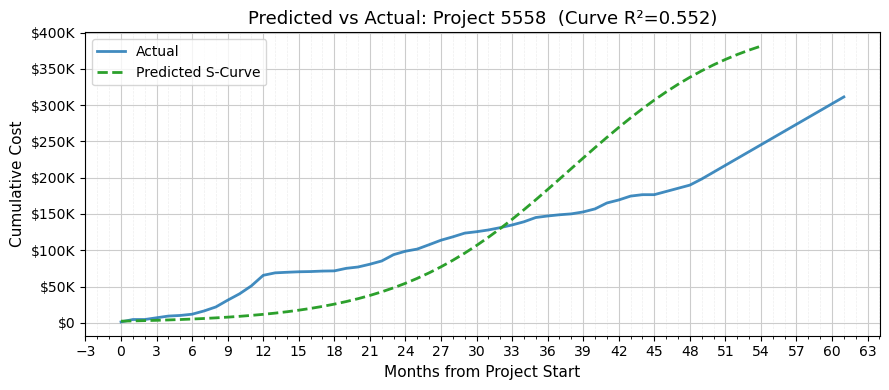

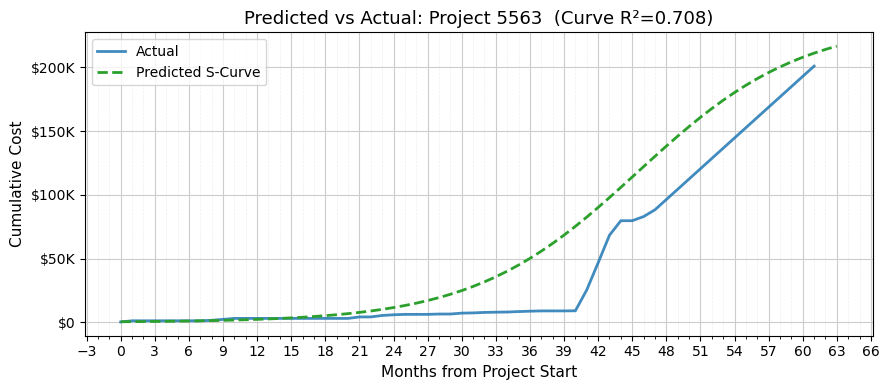

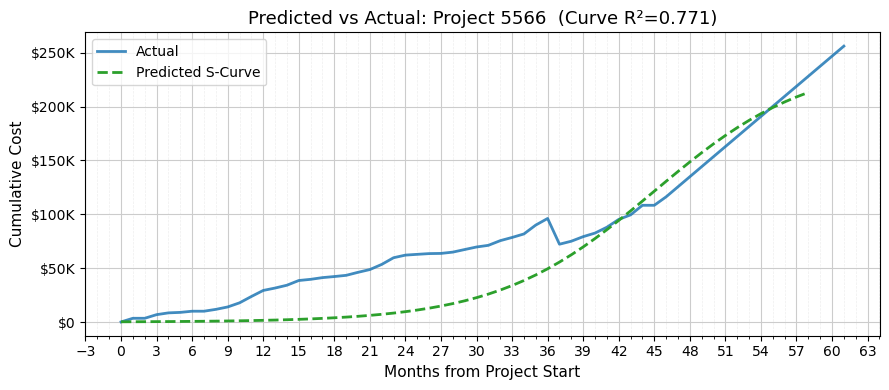

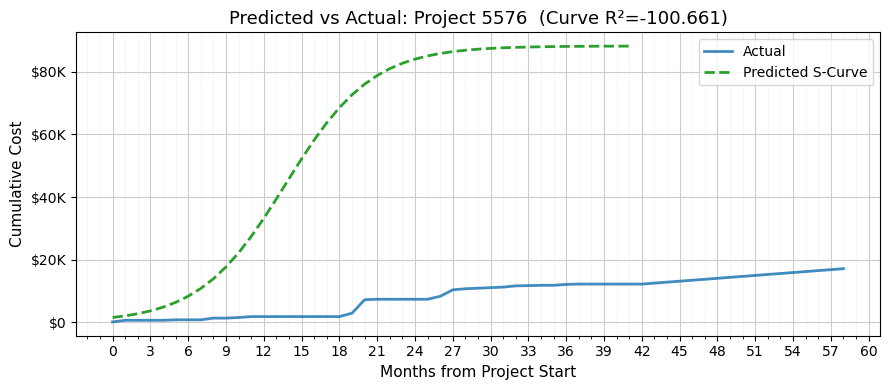

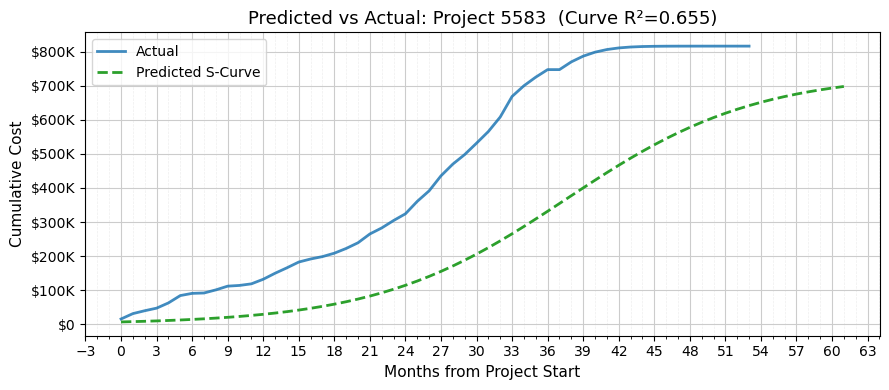

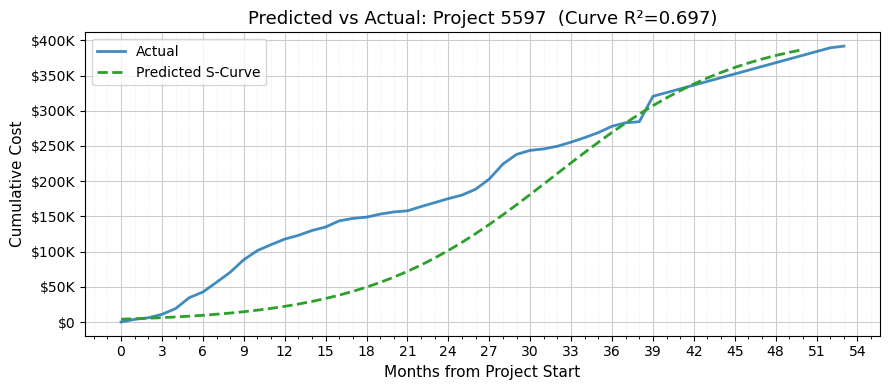

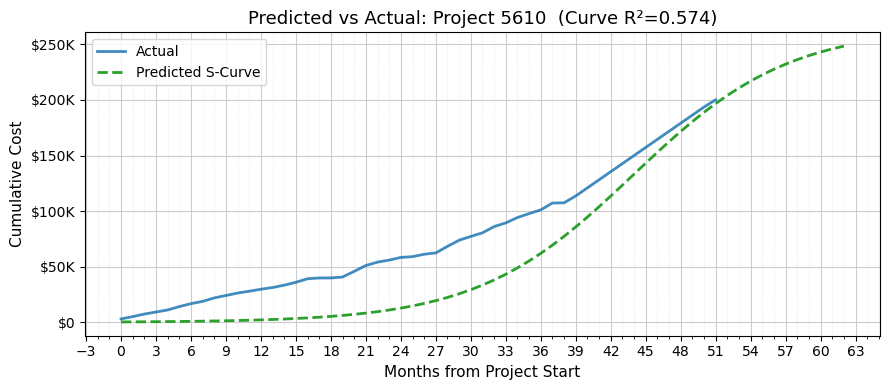

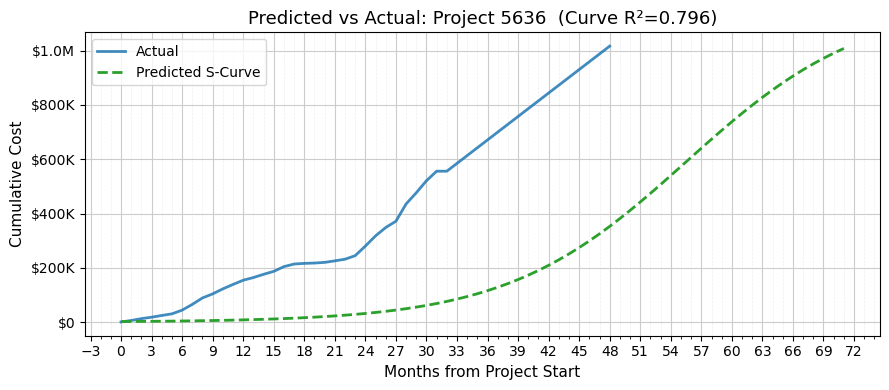

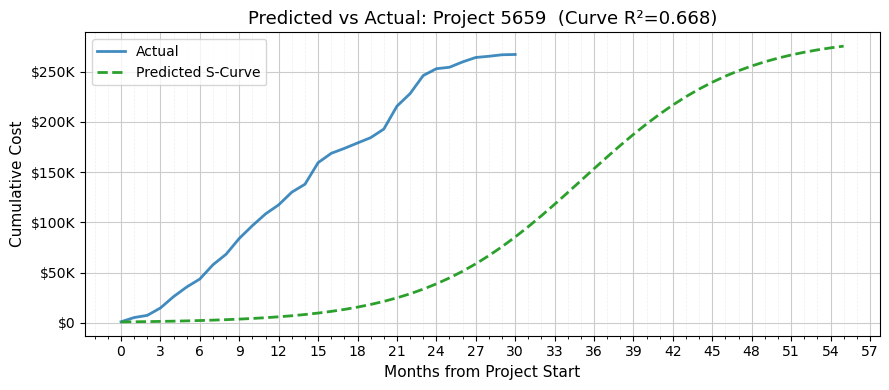

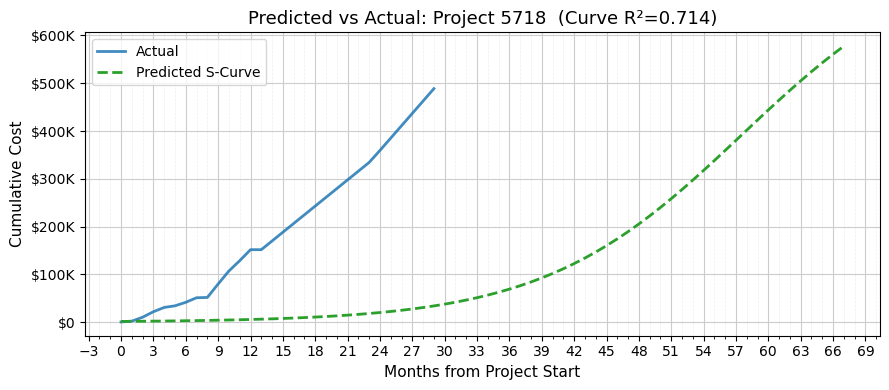

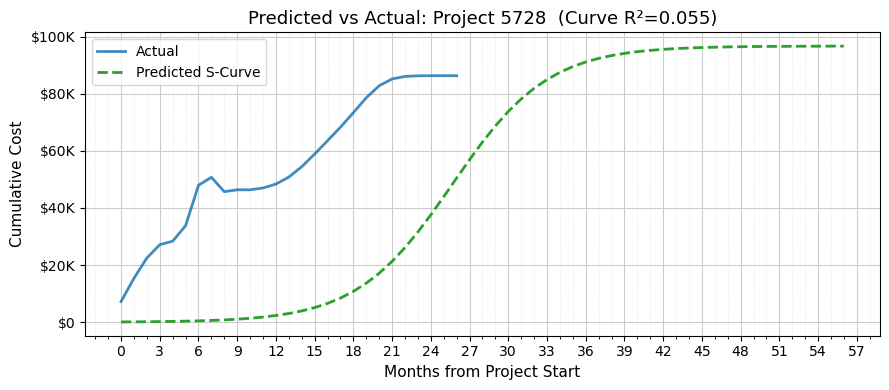

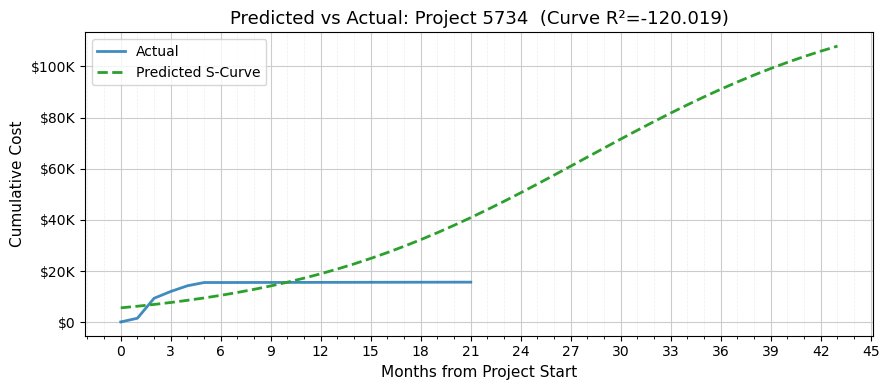

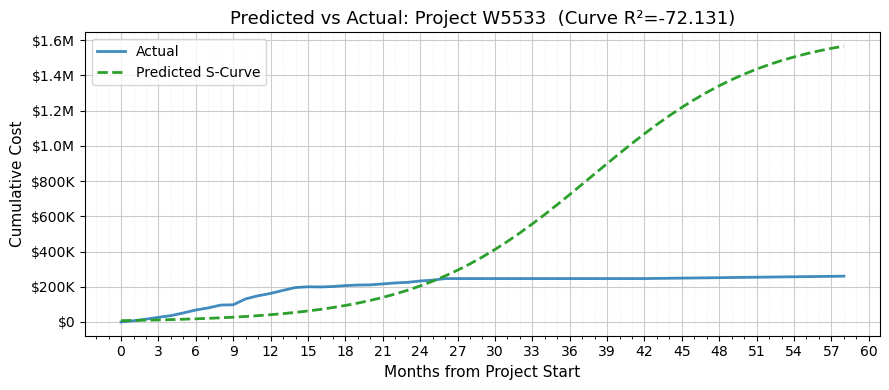

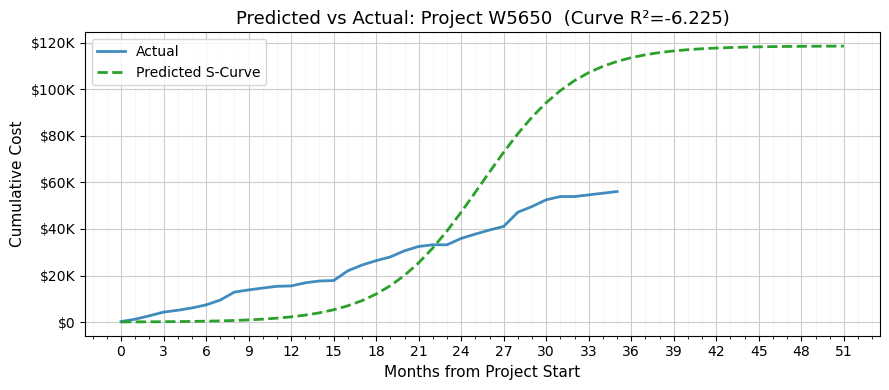

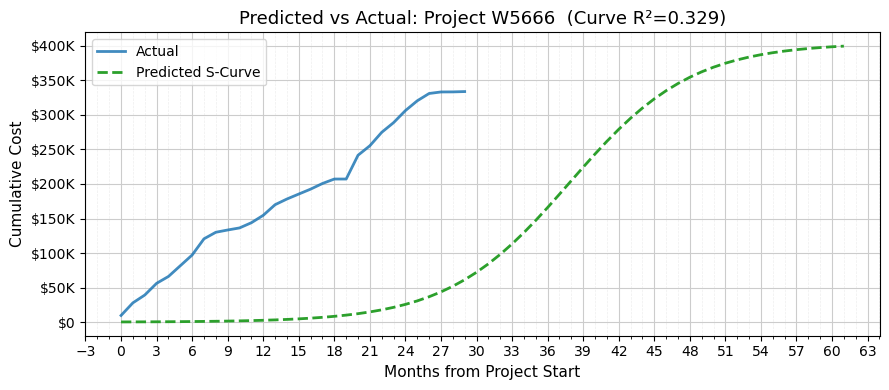


=== RECONSTRUCTION SUMMARY ===
Project Code     Curve_R2
        5018 -6737.574451
        5734  -120.018898
        5576  -100.660971
       W5533   -72.131097
       W5650    -6.224587
        5531    -5.534308
        5323    -1.999911
        5530    -1.441638
        5467    -0.970852
        5540    -0.599345
        5482    -0.380955
        5728     0.055159
        5253     0.154014
        5282     0.240014
        5529     0.294399
       W5666     0.328853
        5372     0.337644
        5537     0.342454
        5528     0.432603
        5527     0.450402
        5148     0.459264
        5558     0.552130
        5610     0.573963
        5583     0.655347
        5659     0.667808
        5088     0.687504
        5597     0.696577
        5563     0.707557
        5718     0.714491
        5493     0.734547
        5486     0.763338
        5566     0.771112
        5548     0.772873
        5199     0.781088
        5171     0.792459
        5636     0.796308
      

In [21]:
########################################################
"""

RECONSTRUCTION VALIDATION
Compare each project's predicted S-curve to its actual cumulative spend.
Uses LOO out-of-fold predictions — no data leakage.

"""
########################################################

from matplotlib.ticker import MultipleLocator, FuncFormatter

def format_currency(x, pos):
    if x >= 1e6:
        return f'${x * 1e-6:.1f}M'
    elif x >= 1e3:
        return f'${x * 1e-3:.0f}K'
    return f'${x:,.0f}'

timeline_dates_full = pd.date_range(start='2011-01-01', end='2027-06-01', freq='MS')
timeline_cols_full  = timeline_dates_full.strftime('%b %Y').tolist()

reconstruction_results = []

for idx, row in all_projects_df.iterrows():
    pc = row['Project Code']
    actual_row = all_projects_df_2[all_projects_df_2['Project Code'] == pc]
    if actual_row.empty:
        continue

    y_full    = actual_row[timeline_cols_full].values[0].astype(float)
    start_i   = np.argmax(y_full > 0)
    actual_dur = max(1, int(row['Duration_Months']))
    y_actual  = y_full[start_i : start_i + actual_dur]

    pred_dur = max(1, int(loo_predictions['Duration_Months'][idx]))
    pred_L   = loo_predictions['S_Curve_L'][idx]
    pred_k   = loo_predictions['S_Curve_k'][idx]
    pred_t0  = loo_predictions['S_Curve_t0'][idx]

    y_pred_curve = logistic_curve(np.arange(pred_dur), pred_L, pred_k, pred_t0)

    # Interpolate to common length for R^2 comparison
    n   = min(pred_dur, actual_dur)
    y_a = np.interp(np.linspace(0, 1, n), np.linspace(0, 1, actual_dur), y_actual)
    y_p = np.interp(np.linspace(0, 1, n), np.linspace(0, 1, pred_dur),   y_pred_curve)
    ss_tot   = np.sum((y_a - y_a.mean()) ** 2)
    curve_r2 = 1 - np.sum((y_a - y_p) ** 2) / ss_tot if ss_tot > 0 else np.nan
    reconstruction_results.append({'Project Code': pc, 'Curve_R2': curve_r2})

    # Plot predicted vs actual
    fig, ax = plt.subplots(figsize=(9, 4))
    ax.plot(np.arange(actual_dur), y_actual,    linewidth=2, color='#1f77b4', label="Actual", alpha=0.85)
    ax.plot(np.arange(pred_dur),   y_pred_curve, linewidth=2, color='#2ca02c', linestyle='--', label="Predicted S-Curve")
    ax.set_title(f"Predicted vs Actual: Project {pc}  (Curve R²={curve_r2:.3f})", fontsize=13)
    ax.set_xlabel("Months from Project Start", fontsize=11)
    ax.set_ylabel("Cumulative Cost", fontsize=11)
    ax.yaxis.set_major_formatter(FuncFormatter(format_currency))
    ax.xaxis.set_major_locator(MultipleLocator(3))
    ax.xaxis.set_minor_locator(MultipleLocator(1))
    plt.grid(which='major', color='#CCCCCC', linestyle='-',  linewidth=0.8)
    plt.grid(which='minor', color='#EEEEEE', linestyle='--', linewidth=0.5)
    plt.legend()
    plt.tight_layout()
    plt.show()

recon_df = pd.DataFrame(reconstruction_results)
print("\n=== RECONSTRUCTION SUMMARY ===")
print(recon_df.sort_values('Curve_R2').to_string(index=False))
print(f"\nMedian Curve R²: {recon_df['Curve_R2'].median():.4f}")
print(f"Projects with R² > 0.8: {(recon_df['Curve_R2'] > 0.8).sum()} / {len(recon_df)}")

Following this stage of the process, we have a solid baseline, but as always WE NEED MORE DATA for the accuracy to be better!!! It can only be so accurate with only ~50 examples!!! If we could get this number up to like 200 I imagine the performance would improve a lot

Still this is a fine place to start; we can expand the training data by adding projection CSVs to the "sq" folder and adding corresponding rows to the gross_sq.csv spreadsheet

But more data WITH the square footage is really the true bottleneck. I built a separate pipeline using a larger set of projections files (which did not require gross sq footage) and for some reason the model is much worse at predicting the growth rate of the S-curve without gross sq footage, which results in the predicted S-Curves having very poor R^2 score


Some more testing: overall stats (Median R^2 and Proj's with R^2 > 0.8)

### Trial 1
**Median R^2:** 0.617

**Count R^2 > 0.8:** 18

### Trial 2
**Median R^2:** 0.633

**Count R^2 > 0.8:** 18

### Trial 3
**Median R^2:** 0.6277

**Count R^2 > 0.8:** 21

### Trial 4
**Median R^2:** 0.6658

**Count R^2 > 0.8:** 17

### Trial 5
**Median R^2:** 0.6458

**Count R^2 > 0.8:** 16

In [ ]:
"""

# Export the models to "trained_models"

import joblib
from pathlib import Path

output_dir = Path("trained_models")
output_dir.mkdir(exist_ok=True)
for target_name, model in best_models.items():
    file_path = output_dir / f"{target_name}_model_l6_v1.joblib"
    joblib.dump(model, file_path)
    print(f"Success: Exported {target_name} model to {file_path}")

"""


Success: Exported Duration_Months model to trained_models/Duration_Months_model_l6_v1.joblib
Success: Exported S_Curve_L model to trained_models/S_Curve_L_model_l6_v1.joblib
Success: Exported S_Curve_k model to trained_models/S_Curve_k_model_l6_v1.joblib
Success: Exported S_Curve_t0 model to trained_models/S_Curve_t0_model_l6_v1.joblib
